In [1]:
import pandas as pd
from src.setup import get_base
from src.feature_engineering import engineer_features, engineer_features2, engineer_features_combined, engineer_features_optimized, engineer_features_focused
from sklearn.preprocessing import StandardScaler
from src.clustering import SegmentationPipeline

In [2]:
df = get_base()

In [3]:
df_features = engineer_features2(df)

/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_discount_ratio"] = grouped.apply(
/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:214: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_hotel_combo_ratio"] = grouped.apply(


In [4]:
pipe = SegmentationPipeline(variance_threshold=0.95, max_clusters=10)

In [ ]:
# Features vorbereiten
features_scaled, df_clean = pipe.prepare_features(df_features)

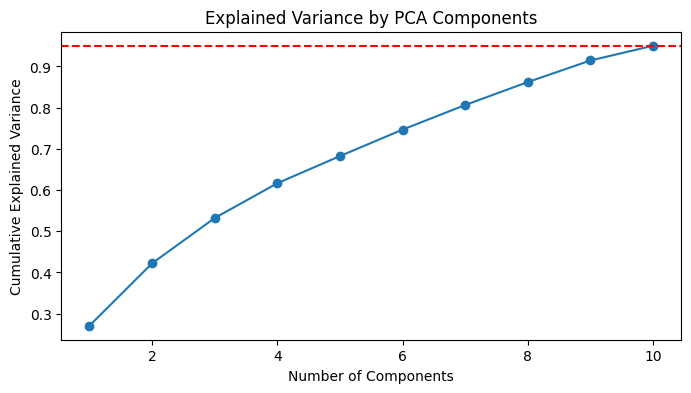

In [6]:
# PCA
components, pca, explained_var = pipe.run_pca(features_scaled)
pipe.plot_explained_variance()

KMeans with 2 clusters: 0.1709
KMeans with 3 clusters: 0.3298
KMeans with 4 clusters: 0.1773
KMeans with 5 clusters: 0.1869
KMeans with 6 clusters: 0.1778
KMeans with 7 clusters: 0.1840
KMeans with 8 clusters: 0.1977
KMeans with 9 clusters: 0.1884
KMeans with 10 clusters: 0.1808


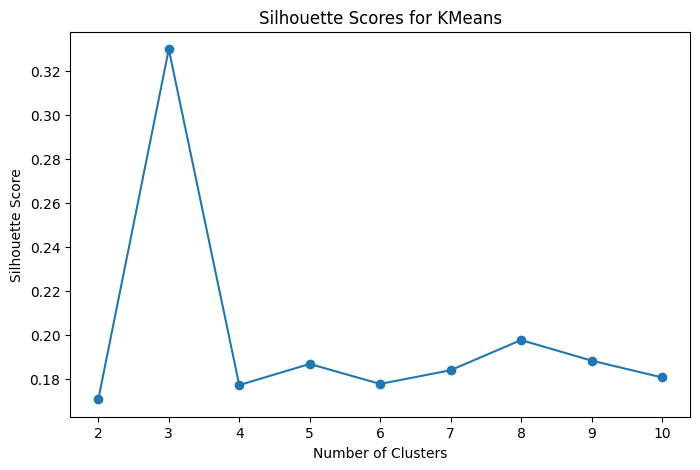

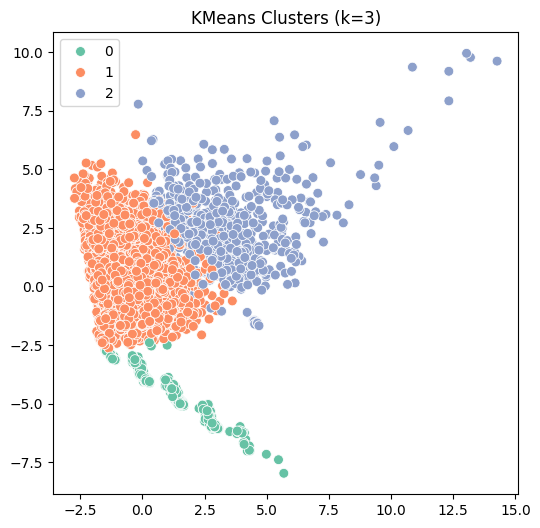

In [7]:
# 1. Variante: Automatisch bestes k wählen
model_auto, scores_auto = pipe.optimized_kmeans_clustering()
pipe.plot_scores()
pipe.plot_clusters()

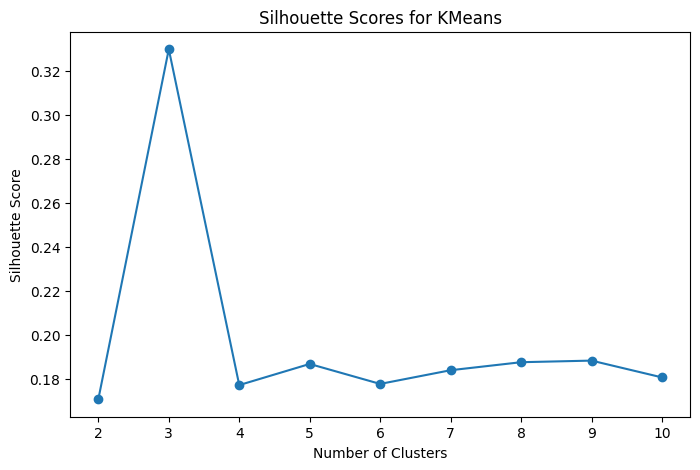

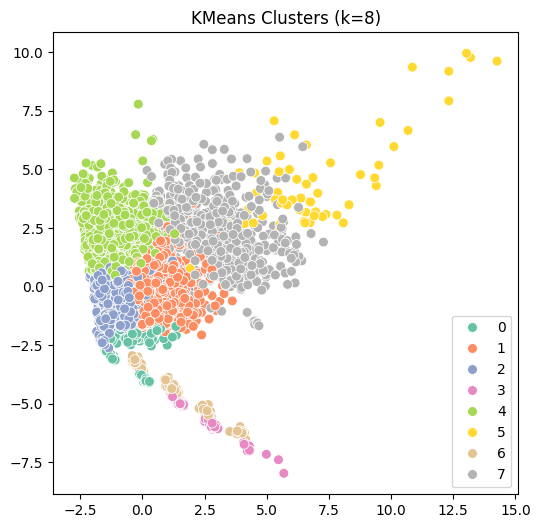

In [8]:
model_fixed, scores_fixed = pipe.kmeans_clustering(n_clusters=8)
pipe.plot_scores()
pipe.plot_clusters()

In [9]:
df_features

,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
user_id,,,,,,,,,,,,,,,,,,
23557,66,0.0,1,0,0,0.000000,0.00,0,2,0,0.000,0.000000,0.000000,0.000000,0,0.000000,0.000,1.000000
94883,53,0.0,1,0,2,432.045000,864.09,2,2,0,0.000,0.000000,0.000000,0.500000,0,0.000000,0.250,0.500000
101486,52,0.0,1,1,1,189.910000,189.91,1,2,2,0.250,1.999998,0.010531,0.000000,0,0.000000,0.125,0.666666
101961,45,0.0,1,0,5,248.532000,1242.66,5,5,2,0.250,0.400000,0.001609,0.400000,0,0.000000,0.625,0.500000
106907,46,0.0,1,1,1,13902.060000,27804.12,2,2,1,0.125,0.500000,0.000036,4.999998,1,0.250000,0.250,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792549,47,0.0,0,0,4,259.792500,1039.17,4,1,1,0.125,0.250000,0.000962,0.500000,0,0.000000,0.125,0.200000
796032,52,0.0,1,0,3,1305.410000,5221.64,4,3,2,0.250,0.500000,0.000383,1.250000,1,0.142857,0.375,0.428571
801660,55,0.0,1,1,1,136.653333,409.96,3,3,3,0.375,1.000000,0.007318,0.333333,0,0.000000,0.375,0.500000


In [10]:
df_clusters = pipe.assign_clusters(df_features)

# Überblick
summary = pipe.cluster_summary(df_clusters)
summary.to_csv('../report/summary_clusters.csv')


display(summary)
print(summary)

# Einfachere Übersicht: Cluster-Mittelwerte
means = pipe.cluster_means(df_clusters)
display(means)

age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    min    max count   
cluster                                                       
0                       0.000000  0.000  0.000  0.000   363   
1                       0.226040  0.250  0.000  0.625  1490   
2                       0.175418  0.125  0.000  0.375  1532   
3                       0.000000  0.000  0.000  0.000   184   
4                       0.447160  0.400  0.125  1.000  1554   
5                       0.235077  0.250  0.000  0.625    61   
6                       0.000000  0.000  0.000  0.000   274   
7                       0.380444  0.375  0.100  0.875   540   

        hotel_booking_ratio                                      
                       mean    median       min       max count  
cluster                                                          
0                  0.000000  0.000000  0.000000  0.000000   363  
1                  0.512120  0.500000  0.000000  0.800000  1490  
2                  0.540641  0.500000  0.000000  1.000000  1532  
3                  0.010870  0.000000  0.000000  0.999999   184  
4                  0.496391  0.500000  0.200000  0.666667  1554  
5                  0.457081  0.500000  0.250000  0.800000    61  
6                  0.999999  0.999999  0.999999  1.000000   274  
7                  0.487094  0.500000  0.250000  0.800000   540  

[8 rows x 90 columns]

               age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    mi

,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
cluster,,,,,,,,,,,,,,,,,,
0,40.115702,0.123967,0.399449,0.336088,0.256198,112.422259,125.547355,0.258953,0.000000,0.779614,0.096191,4.848488e+05,4.848485e+05,0.126722,0.000000,0.000000,0.000000,0.000000
1,43.740268,0.112081,0.475168,0.348993,2.038926,446.724712,928.064409,2.122819,2.250336,2.534228,0.309720,1.443467e+00,6.350137e-03,0.571331,0.000000,0.000000,0.226040,0.512120
2,42.380548,0.124674,0.460836,0.359661,1.632507,437.837757,775.683557,1.699739,1.894909,0.578329,0.071184,3.864227e-01,1.572916e-03,0.562391,0.000000,0.000000,0.175418,0.540641
3,39.864130,0.114130,0.391304,0.309783,0.000000,0.000000,0.000000,0.000000,0.010870,2.413043,0.294257,2.413043e+06,2.413043e+06,0.000000,0.000000,0.000000,0.000000,0.010870
4,45.073359,0.102960,0.413771,0.254826,3.749678,439.394378,1760.118546,4.013514,3.969112,1.035393,0.126097,2.636493e-01,7.461947e-04,0.564251,0.002574,0.000162,0.447160,0.496391
5,41.967213,0.180328,0.786885,0.672131,1.803279,5438.038500,12958.658033,2.622951,2.278689,2.147541,0.265021,9.027318e-01,1.935356e-04,2.114480,0.819672,0.174246,0.235077,0.457081
6,41.003650,0.083942,0.408759,0.372263,0.000000,0.000000,0.000000,0.000000,1.266423,1.751825,0.213279,1.751825e+06,1.751825e+06,0.000000,0.000000,0.000000,0.000000,0.999999
7,42.000000,0.142593,0.385185,0.312963,2.468519,720.985920,2436.303056,3.620370,3.518519,2.342593,0.284226,7.589966e-01,4.259259e+04,0.612703,1.025926,0.166527,0.380444,0.487094


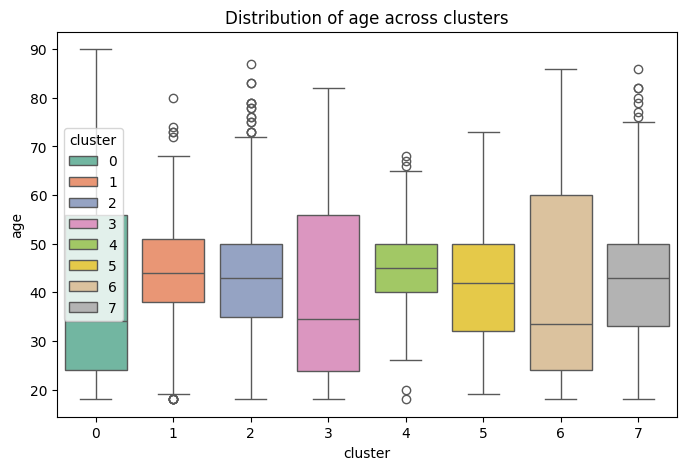

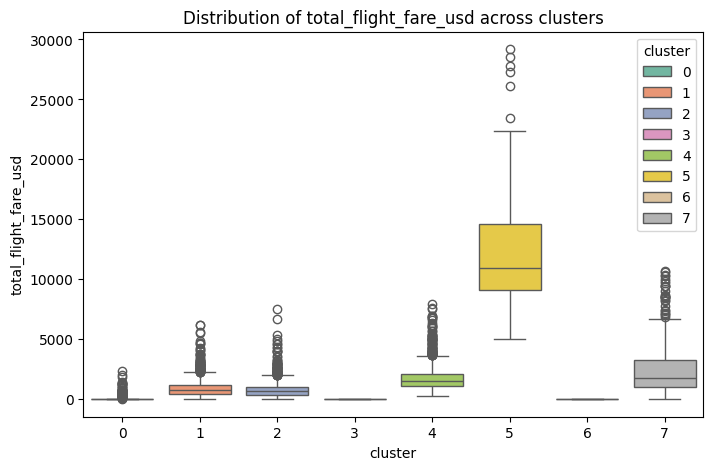

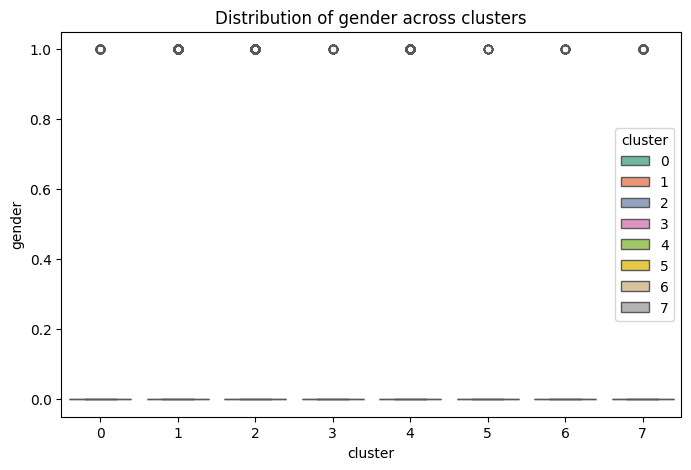

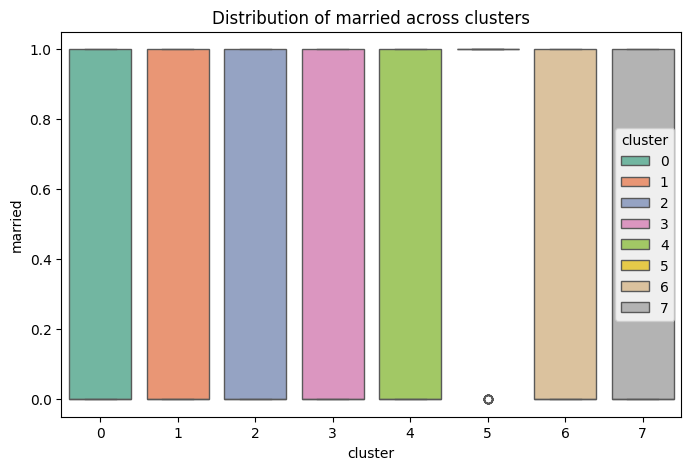

In [11]:
pipe.plot_cluster_feature(df_clusters, "age")

pipe.plot_cluster_feature(df_clusters, "total_flight_fare_usd")

pipe.plot_cluster_feature(df_clusters, "gender")

pipe.plot_cluster_feature(df_clusters, "married")

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_32894/1022984540.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x='cluster', y='age', palette=colors)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_32894/1022984540.py:25: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_clusters, x='cluster', y='age', palette=colors)


KeyError: "Columns not found: 'avg_clicks'"

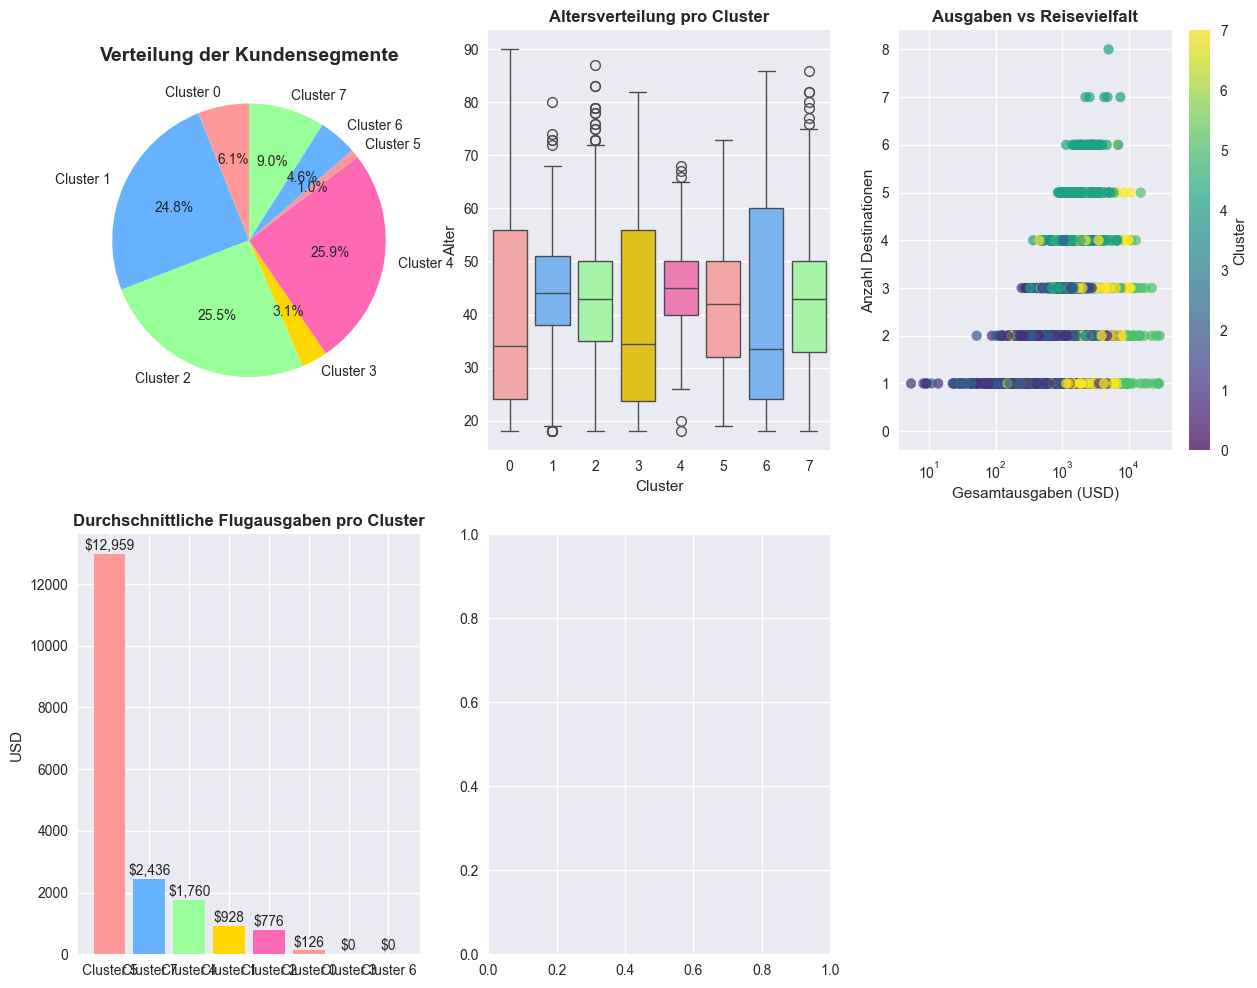

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

# Styling für professionelle Plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cluster zuordnen
df_clusters = pipe.assign_clusters(df_features)

# 1. CLUSTER GRÖSSEN - Pie Chart
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FF69B4']
plt.pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Verteilung der Kundensegmente', fontsize=14, fontweight='bold')

# 2. ALTERSVERTEILUNG - Boxplot
plt.subplot(2, 3, 2)
sns.boxplot(data=df_clusters, x='cluster', y='age', palette=colors)
plt.title('Altersverteilung pro Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Alter')

# 3. AUSGABEN vs DESTINATIONEN - Scatter Plot
plt.subplot(2, 3, 3)
scatter = plt.scatter(df_clusters['total_flight_fare_usd'],
                     df_clusters['n_unique_destinations'],
                     c=df_clusters['cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Gesamtausgaben (USD)')
plt.ylabel('Anzahl Destinationen')
plt.title('Ausgaben vs Reisevielfalt', fontweight='bold')
plt.xscale('log')  # Log-Skala wegen Extremwerten

# 4. DURCHSCHNITTLICHE AUSGABEN - Bar Chart
plt.subplot(2, 3, 4)
cluster_means = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean().sort_values(ascending=False)
bars = plt.bar(range(len(cluster_means)), cluster_means.values, color=colors)
plt.xticks(range(len(cluster_means)), [f'Cluster {i}' for i in cluster_means.index])
plt.title('Durchschnittliche Flugausgaben pro Cluster', fontweight='bold')
plt.ylabel('USD')
# Werte auf Balken anzeigen
for bar, value in zip(bars, cluster_means.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${value:,.0f}', ha='center', va='bottom')

# 5. FEATURE-HEATMAP - Cluster Charakteristika
plt.subplot(2, 3, 5)
# Wichtige Features auswählen
important_features = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                     'total_flights_booked', 'total_hotels_booked', 'avg_clicks']
cluster_summary = df_clusters.groupby('cluster')[important_features].mean()

# Normalisieren für bessere Darstellung
cluster_summary_normalized = (cluster_summary - cluster_summary.mean()) / cluster_summary.std()

sns.heatmap(cluster_summary_normalized.T, annot=True, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Standardisierte Werte'})
plt.title('Cluster Charakteristika (standardisiert)', fontweight='bold')
plt.ylabel('Features')

# 6. GESCHLECHTERVERTEILUNG - Stacked Bar Chart
plt.subplot(2, 3, 6)
gender_by_cluster = pd.crosstab(df_clusters['cluster'], df_clusters['gender'])
gender_by_cluster.plot(kind='bar', stacked=True, color=['pink', 'lightblue'], ax=plt.gca())
plt.title('Geschlechterverteilung pro Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Anzahl Kunden')
plt.legend(['Weiblich', 'Männlich'])

plt.tight_layout()
plt.show()

# 7. DETAILIERTE CLUSTER-PROFILE
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig)

# Radar Chart für Cluster-Profile
ax1 = fig.add_subplot(gs[0, 0])
features_for_radar = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                     'total_flights_booked', 'avg_clicks']
radar_data = cluster_summary_normalized[features_for_radar]

angles = np.linspace(0, 2*np.pi, len(features_for_radar), endpoint=False).tolist()
angles += angles[:1]  # Kreis schließen

for cluster_idx in radar_data.index:
    values = radar_data.loc[cluster_idx].values.tolist()
    values += values[:1]  # Kreis schließen
    ax1.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_idx}')
    ax1.fill(angles, values, alpha=0.1)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(features_for_radar)
ax1.set_yticklabels([])
ax1.set_title('Cluster Profile Vergleich', fontweight='bold', size=14)
ax1.legend()

# 8. WERT DER KUNDENGRUPPEN
ax2 = fig.add_subplot(gs[0, 1])
total_revenue_by_cluster = df_clusters.groupby('cluster')['total_flight_fare_usd'].sum()
avg_revenue_per_customer = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean()

x = range(len(total_revenue_by_cluster))
width = 0.35

bars1 = ax2.bar(x, total_revenue_by_cluster.values, width, label='Gesamtumsatz', alpha=0.7)
bars2 = ax2.bar([i + width for i in x], avg_revenue_per_customer.values, width,
                label='Umsatz pro Kunde', alpha=0.7)

ax2.set_xlabel('Cluster')
ax2.set_ylabel('USD')
ax2.set_title('Wirtschaftliche Bedeutung der Cluster', fontweight='bold')
ax2.set_xticks([i + width/2 for i in x])
ax2.set_xticklabels([f'Cluster {i}' for i in total_revenue_by_cluster.index])
ax2.legend()

# Werte anzeigen
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=8)

# 9. BUCHUNGSVERHALTEN
ax3 = fig.add_subplot(gs[1, :])
booking_data = df_clusters.groupby('cluster')[['total_flights_booked', 'total_hotels_booked']].mean()
x = np.arange(len(booking_data))
width = 0.35

bars3 = ax3.bar(x - width/2, booking_data['total_flights_booked'], width,
                label='Flugbuchungen', alpha=0.8)
bars4 = ax3.bar(x + width/2, booking_data['total_hotels_booked'], width,
                label='Hotelbuchungen', alpha=0.8)

ax3.set_xlabel('Cluster')
ax3.set_ylabel('Durchschnittliche Buchungen')
ax3.set_title('Buchungsverhalten pro Cluster', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Cluster {i}' for i in booking_data.index])
ax3.legend()

plt.tight_layout()
plt.show()

# 10. ZUSAMMENFASSENDE STATISTIK
print("="*60)
print("📊 ZUSAMMENFASSUNG DER KUNDENSEGMENTE")
print("="*60)

for cluster in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster]
    print(f"\n🏷️  CLUSTER {cluster} (n={len(cluster_data):,})")
    print(f"   👥 Alter: {cluster_data['age'].mean():.1f} Jahre")
    print(f"   💰 Durchschn. Ausgaben: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   ✈️  Destinationen: {cluster_data['n_unique_destinations'].mean():.1f}")
    print(f"   🎯 Empfehlung: {get_cluster_recommendation(cluster)}")

def get_cluster_recommendation(cluster):
    recommendations = {
        0: "Treue Kunden - Komfort-Angebote, Pauschalreisen",
        1: "Junge Sparer - Budget-Optionen, Flexible Zahlung",
        2: "Aktive Vielflieger - Treueprogramm, Paketangebote",
        3: "Premium-Reisende - Hochwertige Angebote, Personalisierung",
        4: "Ultra-Premium - Exklusive Angebote, Persönlicher Service"
    }
    return recommendations.get(cluster, "Segment analysieren")

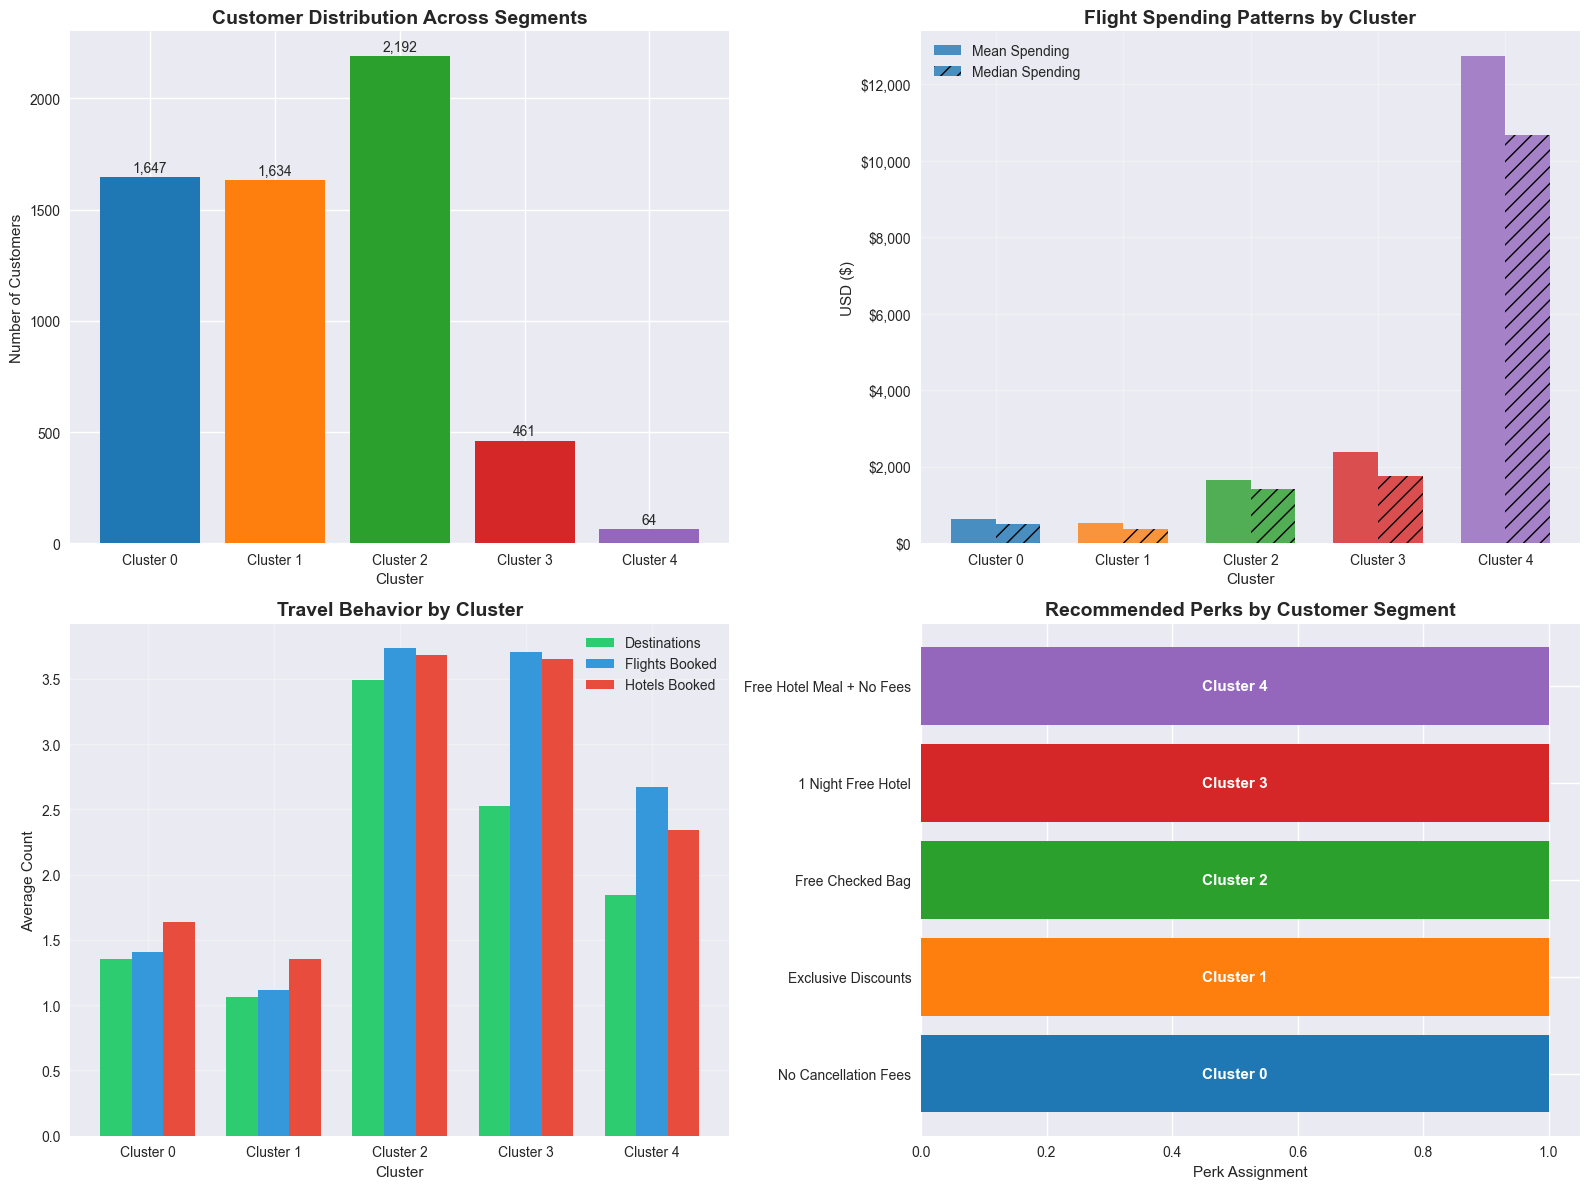

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_3105/2262368151.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = axes[idx].boxplot(box_data, patch_artist=True, labels=[f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())])
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_3105/2262368151.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = axes[idx].boxplot(box_data, patch_artist=True, labels=[f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())])
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_3105/2262368151.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be

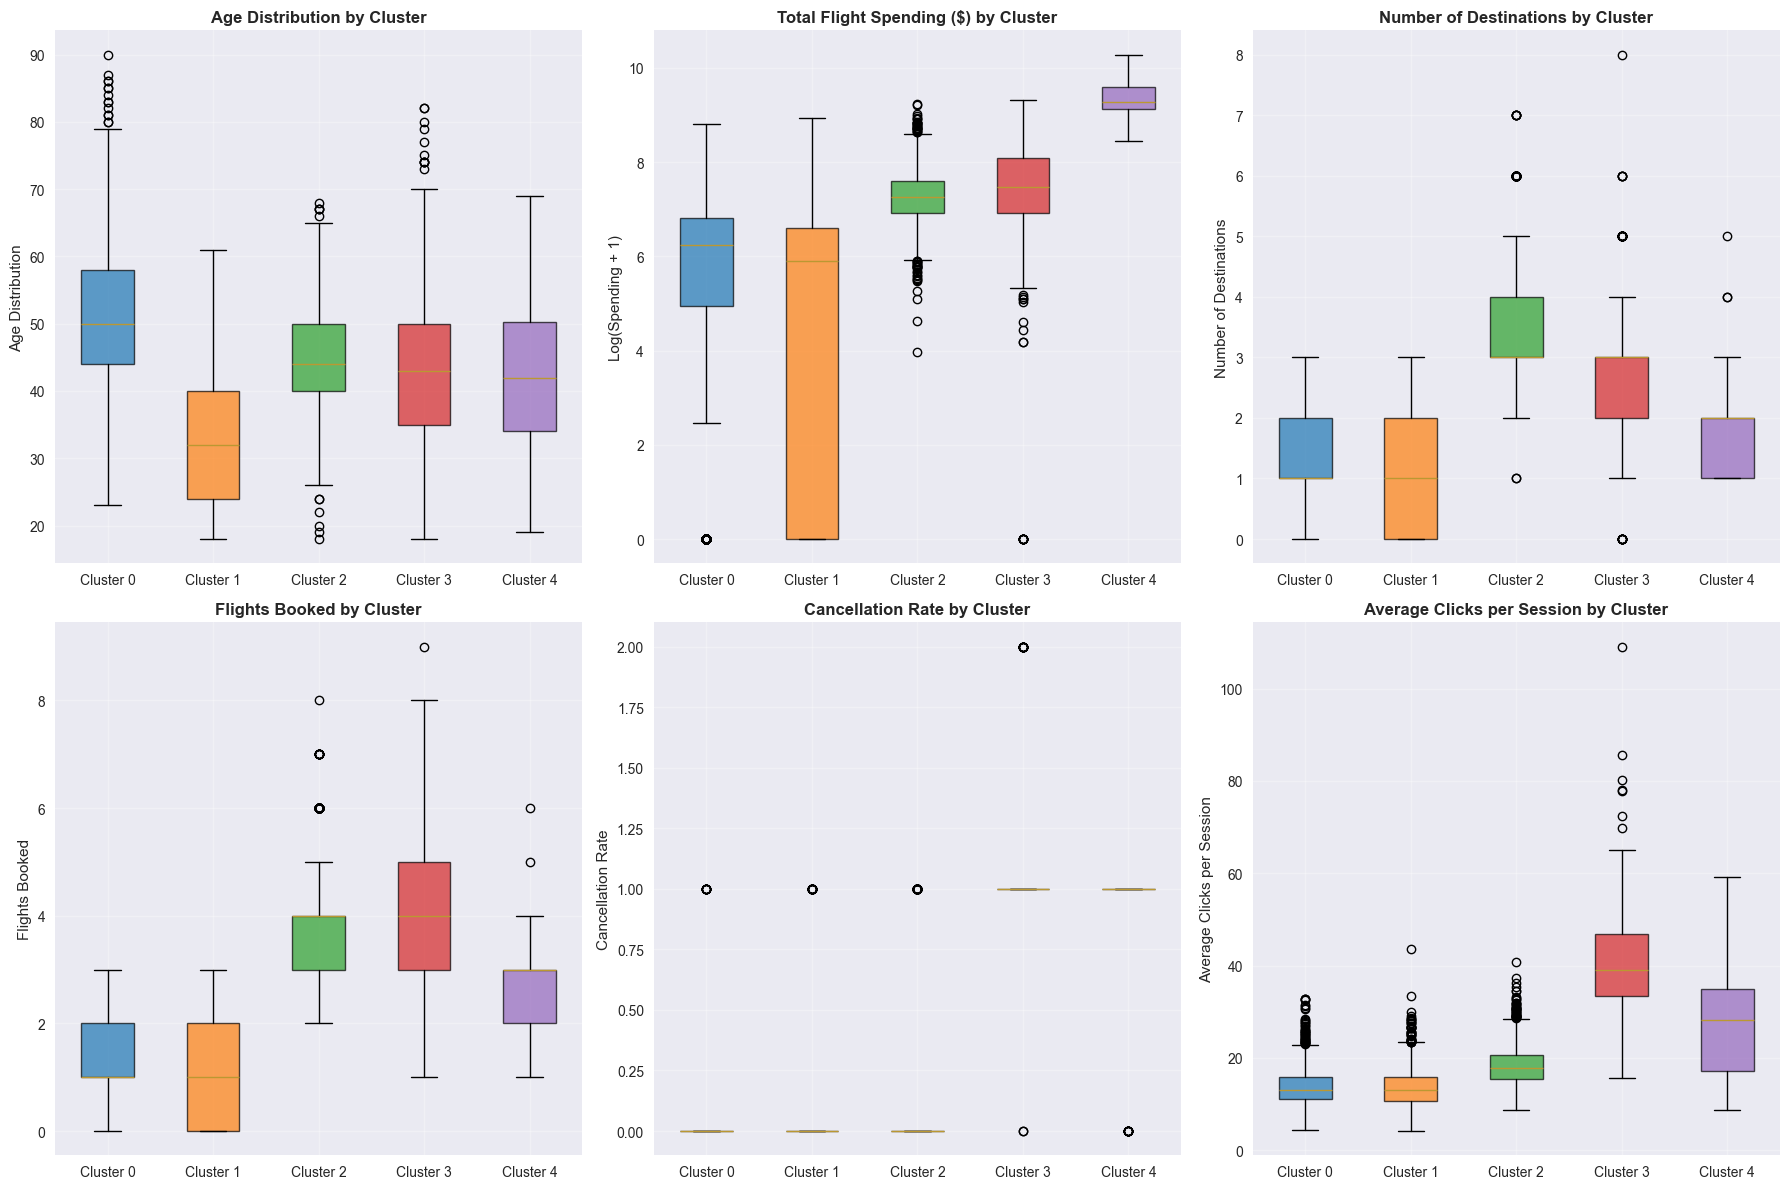

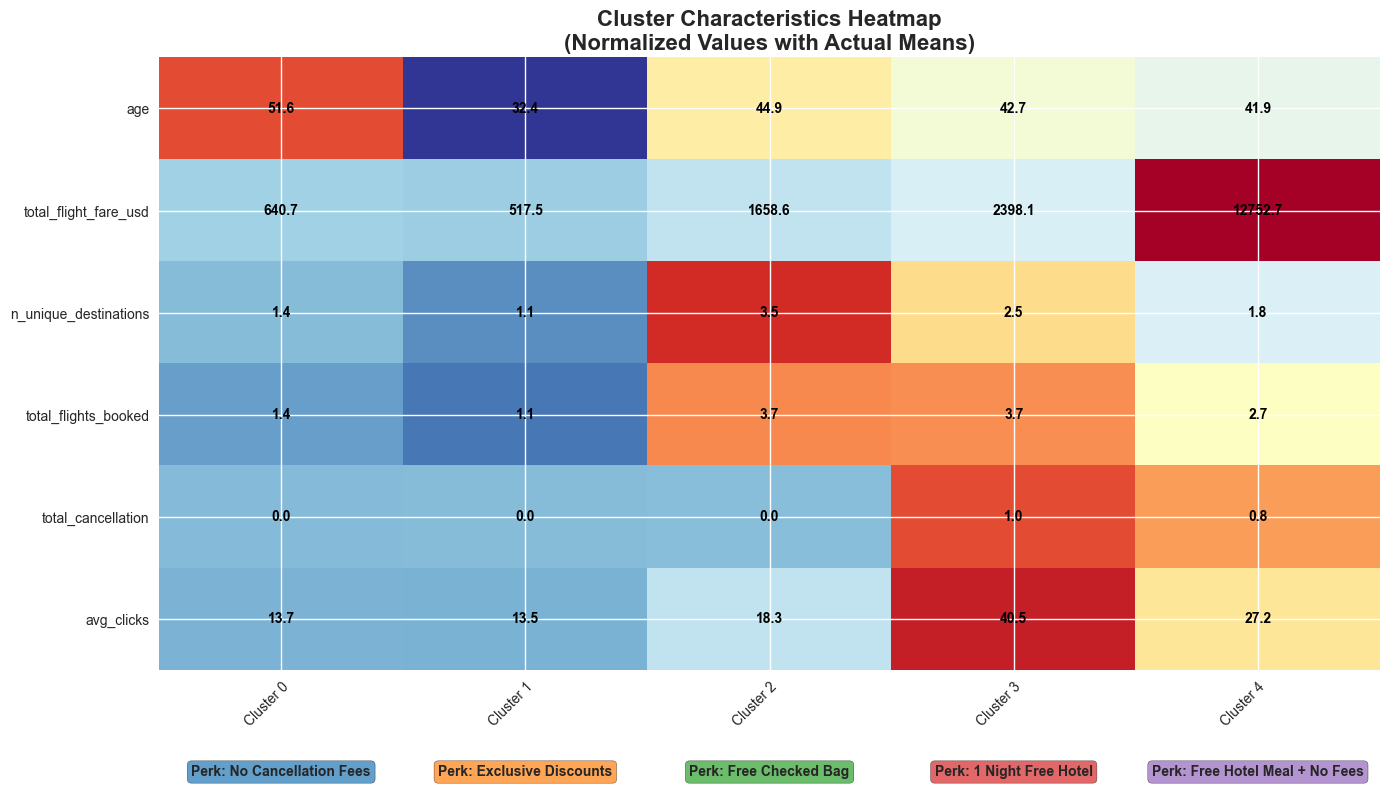

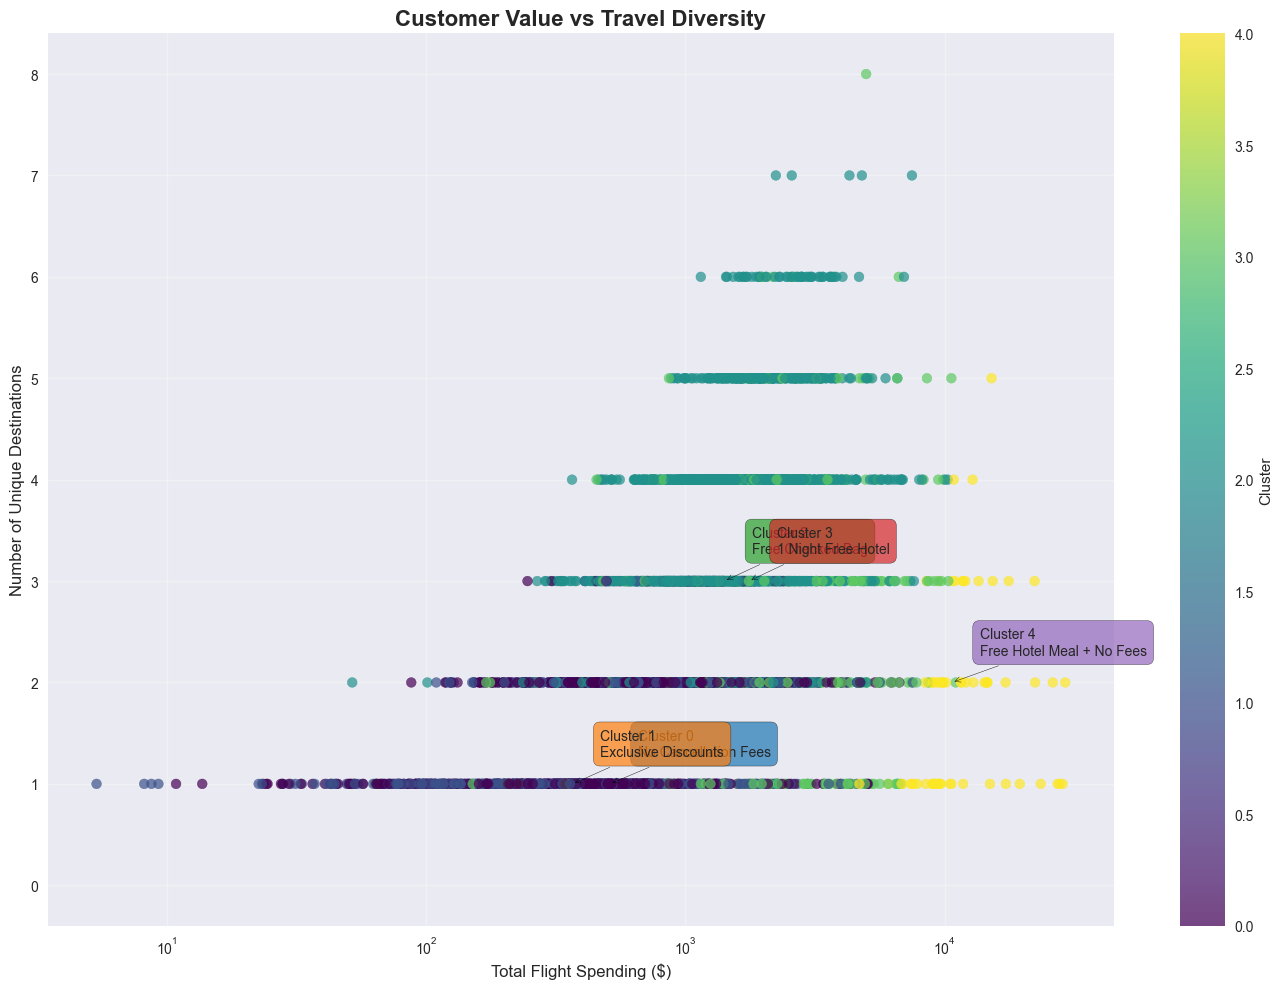

🎯 CLUSTER ANALYSIS SUMMARY - PERK ASSIGNMENTS

🏷️  CLUSTER 0 (n=1,647)


NameError: name 'get_cluster_profile' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Set up professional styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]

# Define perks for each cluster
perk_assignments = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel",
    4: "Free Hotel Meal + No Fees"
}

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. CLUSTER SIZE AND PERK ASSIGNMENT
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Cluster sizes
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
bars = ax1.bar(range(len(cluster_sizes)), cluster_sizes.values, color=cluster_colors)
ax1.set_title('Customer Distribution Across Segments', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Number of Customers')
ax1.set_xticks(range(len(cluster_sizes)))
ax1.set_xticklabels([f'Cluster {i}' for i in cluster_sizes.index])

# Add counts on bars
for bar, count in zip(bars, cluster_sizes.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count:,}', ha='center', va='bottom')

# 2. SPENDING PATTERNS BY CLUSTER
spending_data = df_clusters.groupby('cluster')['total_flight_fare_usd'].agg(['mean', 'median'])
x = np.arange(len(spending_data))
width = 0.35

bars1 = ax2.bar(x - width/2, spending_data['mean'], width, label='Mean Spending', alpha=0.8, color=cluster_colors)
bars2 = ax2.bar(x + width/2, spending_data['median'], width, label='Median Spending', alpha=0.8, color=cluster_colors, hatch='//')

ax2.set_title('Flight Spending Patterns by Cluster', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('USD ($)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Cluster {i}' for i in spending_data.index])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Format y-axis as currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3. TRAVEL BEHAVIOR COMPARISON
travel_metrics = df_clusters.groupby('cluster').agg({
    'n_unique_destinations': 'mean',
    'total_flights_booked': 'mean',
    'total_hotels_booked': 'mean'
})

x = np.arange(len(travel_metrics))
width = 0.25

bars1 = ax3.bar(x - width, travel_metrics['n_unique_destinations'], width, label='Destinations', color='#2ecc71')
bars2 = ax3.bar(x, travel_metrics['total_flights_booked'], width, label='Flights Booked', color='#3498db')
bars3 = ax3.bar(x + width, travel_metrics['total_hotels_booked'], width, label='Hotels Booked', color='#e74c3c')

ax3.set_title('Travel Behavior by Cluster', fontsize=14, fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Average Count')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Cluster {i}' for i in travel_metrics.index])
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. PERK ASSIGNMENT VISUALIZATION
perks = list(perk_assignments.values())
cluster_ids = list(perk_assignments.keys())

ax4.barh(range(len(perks)), [1]*len(perks), color=cluster_colors)
ax4.set_yticks(range(len(perks)))
ax4.set_yticklabels(perks)
ax4.set_xlabel('Perk Assignment')
ax4.set_title('Recommended Perks by Customer Segment', fontsize=14, fontweight='bold')

# Add cluster labels
for i, cluster_id in enumerate(cluster_ids):
    ax4.text(0.5, i, f'Cluster {cluster_id}', ha='center', va='center',
             fontweight='bold', color='white', fontsize=11)

plt.tight_layout()
plt.show()

# 5. DETAILED FEATURE COMPARISON ACROSS CLUSTERS
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = [
    ('age', 'Age Distribution'),
    ('total_flight_fare_usd', 'Total Flight Spending ($)'),
    ('n_unique_destinations', 'Number of Destinations'),
    ('total_flights_booked', 'Flights Booked'),
    ('total_cancellation', 'Cancellation Rate'),
    ('avg_clicks', 'Average Clicks per Session')
]

for idx, (feature, title) in enumerate(features_to_plot):
    if feature == 'total_flight_fare_usd':
        # Use log scale for spending due to large range
        plot_data = np.log1p(df_clusters[feature])
        ylabel = 'Log(Spending + 1)'
    else:
        plot_data = df_clusters[feature]
        ylabel = title

    box_data = [plot_data[df_clusters['cluster'] == i] for i in sorted(df_clusters['cluster'].unique())]
    boxes = axes[idx].boxplot(box_data, patch_artist=True, labels=[f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())])

    # Color the boxes
    for patch, color in zip(boxes['boxes'], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[idx].set_title(f'{title} by Cluster', fontweight='bold')
    axes[idx].set_ylabel(ylabel)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. PERK-CLUSTER MATRIX (Heatmap)
fig, ax = plt.subplots(figsize=(14, 8))

# Create feature matrix for heatmap
heatmap_features = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                   'total_flights_booked', 'total_cancellation', 'avg_clicks']

heatmap_data = df_clusters.groupby('cluster')[heatmap_features].mean()

# Normalize for better visualization
heatmap_data_normalized = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

# Create the heatmap
im = ax.imshow(heatmap_data_normalized.T, cmap='RdYlBu_r', aspect='auto')

# Set labels
ax.set_xticks(np.arange(len(heatmap_data_normalized)))
ax.set_yticks(np.arange(len(heatmap_features)))
ax.set_xticklabels([f'Cluster {i}' for i in heatmap_data_normalized.index])
ax.set_yticklabels(heatmap_features)

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(len(heatmap_features)):
    for j in range(len(heatmap_data_normalized)):
        text = ax.text(j, i, f'{heatmap_data.iloc[j, i]:.1f}',
                       ha="center", va="center", color="black", fontweight='bold')

ax.set_title("Cluster Characteristics Heatmap\n(Normalized Values with Actual Means)",
             fontsize=16, fontweight='bold')

# Add perk assignments as x-label
for i, cluster_id in enumerate(heatmap_data_normalized.index):
    ax.text(i, len(heatmap_features) + 0.5, f"Perk: {perk_assignments[cluster_id]}",
            ha='center', va='center', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=cluster_colors[i], alpha=0.7))

plt.tight_layout()
plt.show()

# 7. CUSTOMER VALUE vs TRAVEL DIVERSITY SCATTER PLOT
plt.figure(figsize=(14, 10))

scatter = plt.scatter(df_clusters['total_flight_fare_usd'],
                     df_clusters['n_unique_destinations'],
                     c=df_clusters['cluster'],
                     cmap='viridis',
                     s=50,
                     alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('Total Flight Spending ($)', fontsize=12)
plt.ylabel('Number of Unique Destinations', fontsize=12)
plt.title('Customer Value vs Travel Diversity', fontsize=16, fontweight='bold')
plt.xscale('log')  # Log scale due to spending outliers

# Add cluster annotations and perk assignments
cluster_centers = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd': 'median',
    'n_unique_destinations': 'median'
})

for cluster_id, center in cluster_centers.iterrows():
    plt.annotate(f'Cluster {cluster_id}\n{perk_assignments[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(20, 20), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=cluster_colors[cluster_id], alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. FINAL SUMMARY DASHBOARD
print("="*80)
print("🎯 CLUSTER ANALYSIS SUMMARY - PERK ASSIGNMENTS")
print("="*80)

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]

    print(f"\n🏷️  CLUSTER {cluster_id} (n={len(cluster_data):,})")
    print(f"   📊 Profile: {get_cluster_profile(cluster_id)}")
    print(f"   💡 Recommended Perk: {perk_assignments[cluster_id]}")
    print(f"   👥 Avg Age: {cluster_data['age'].mean():.1f} years")
    print(f"   💰 Avg Spending: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   ✈️  Avg Destinations: {cluster_data['n_unique_destinations'].mean():.1f}")
    print(f"   📧 Email Focus: '{get_email_focus(cluster_id)}'")

def get_cluster_profile(cluster_id):
    profiles = {
        0: "Mature Loyal Customers - Value security and flexibility",
        1: "Young Budget Travelers - Price-sensitive and practical",
        2: "Active Frequent Travelers - Regular travelers seeking convenience",
        3: "Premium Experience Seekers - Value bundled luxury experiences",
        4: "Ultra-Premium VIPs - Expect multiple premium benefits"
    }
    return profiles.get(cluster_id, "Segment under analysis")

def get_email_focus(cluster_id):
    email_focus = {
        0: "Enjoy peace of mind with No Cancellation Fees",
        1: "Get Exclusive Member-Only Discounts on every trip",
        2: "Travel lighter with Free Checked Bags on all flights",
        3: "Upgrade your stay with 1 Free Hotel Night with flight booking",
        4: "Experience VIP treatment with Complimentary Hotel Dining & Flexible Changes"
    }
    return email_focus.get(cluster_id, "Personalized travel benefits")

# 9. SEGMENT PERFORMANCE METRICS
fig, ax = plt.subplots(figsize=(14, 8))

metrics = ['age', 'total_flight_fare_usd', 'n_unique_destinations', 'total_flights_booked']
metric_names = ['Age', 'Spending', 'Destinations', 'Flights Booked']

# Normalize metrics for radar chart
normalized_metrics = df_clusters.groupby('cluster')[metrics].mean()
normalized_metrics = (normalized_metrics - normalized_metrics.min()) / (normalized_metrics.max() - normalized_metrics.min())

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

for cluster_id in normalized_metrics.index:
    values = normalized_metrics.loc[cluster_id].values.tolist()
    values += values[:1]  # Close the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=cluster_colors[cluster_id])
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names)
ax.set_yticklabels([])
ax.set_title('Cluster Profiles Comparison Radar Chart', fontweight='bold', size=14)
ax.legend(bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.show()

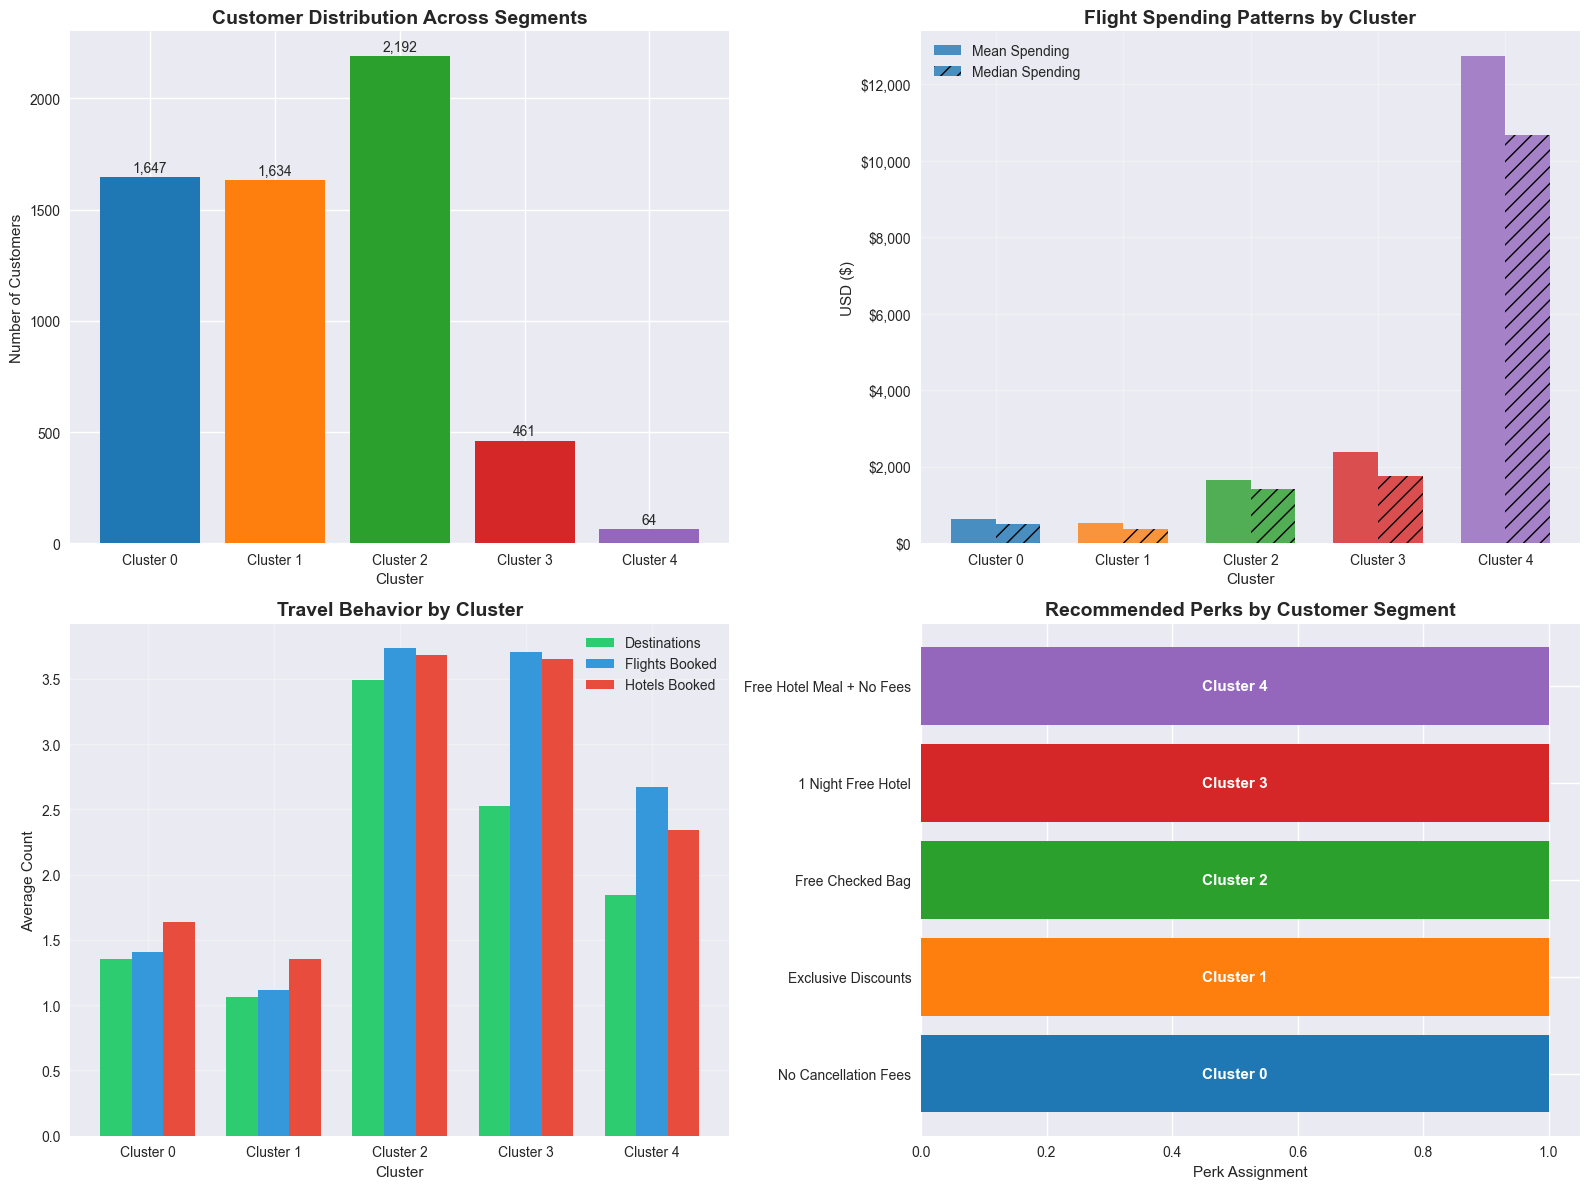

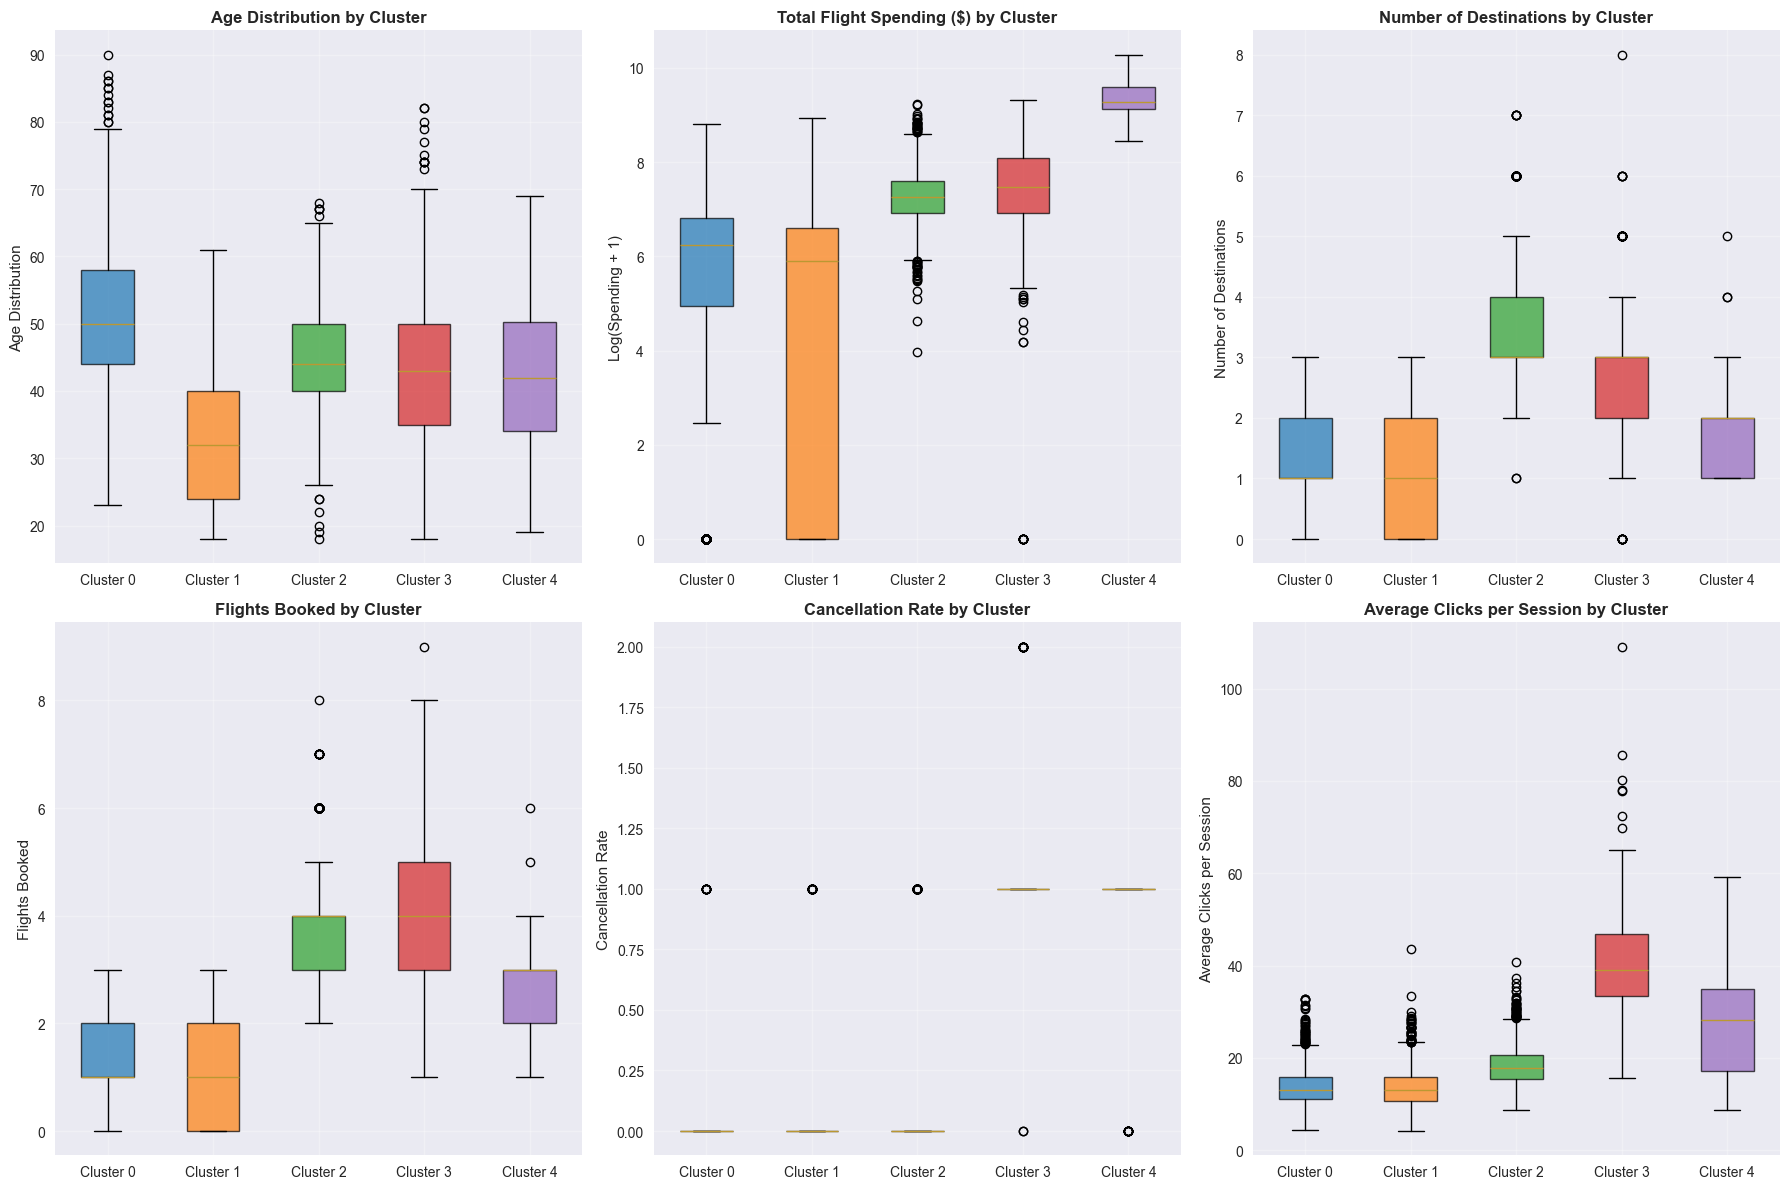

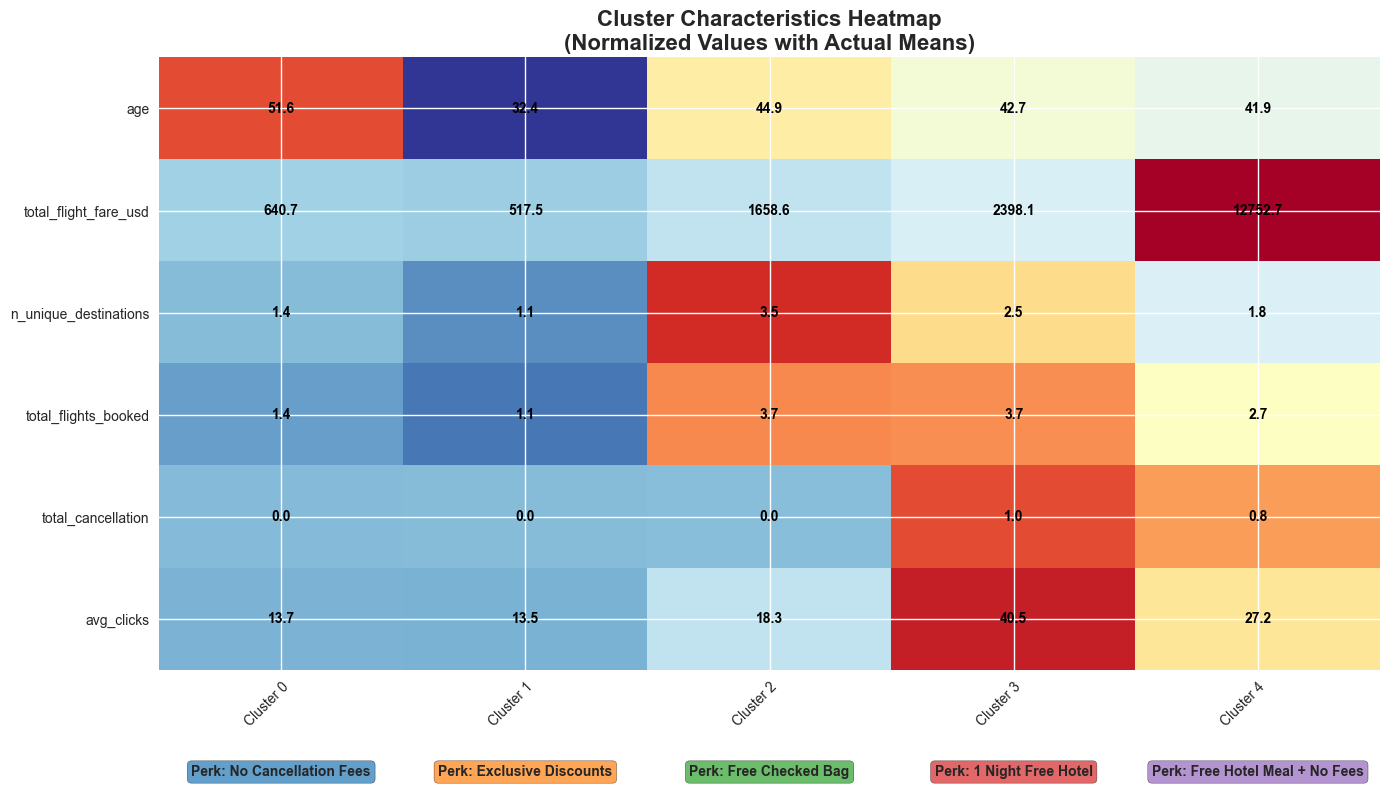

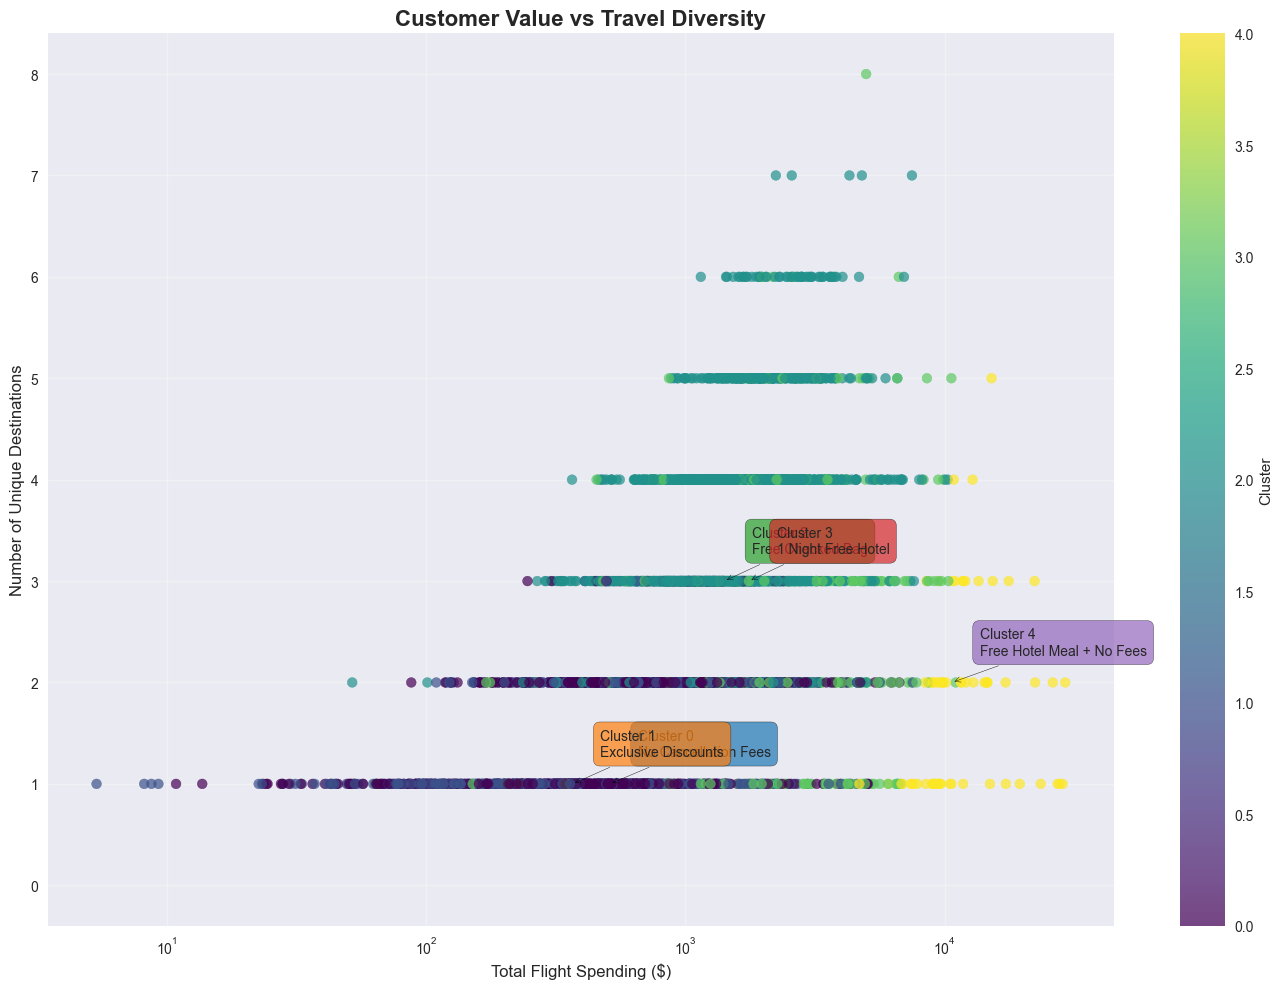

🎯 CLUSTER ANALYSIS SUMMARY - PERK ASSIGNMENTS

🏷️  CLUSTER 0 (n=1,647)


NameError: name 'get_cluster_profile' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Set up professional styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]

# Define perks for each cluster
perk_assignments = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel",
    4: "Free Hotel Meal + No Fees"
}

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. CLUSTER SIZE AND PERK ASSIGNMENT
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Cluster sizes
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
bars = ax1.bar(range(len(cluster_sizes)), cluster_sizes.values, color=cluster_colors)
ax1.set_title('Customer Distribution Across Segments', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Number of Customers')
ax1.set_xticks(range(len(cluster_sizes)))
ax1.set_xticklabels([f'Cluster {i}' for i in cluster_sizes.index])

# Add counts on bars
for bar, count in zip(bars, cluster_sizes.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count:,}', ha='center', va='bottom')

# 2. SPENDING PATTERNS BY CLUSTER
spending_data = df_clusters.groupby('cluster')['total_flight_fare_usd'].agg(['mean', 'median'])
x = np.arange(len(spending_data))
width = 0.35

bars1 = ax2.bar(x - width/2, spending_data['mean'], width, label='Mean Spending', alpha=0.8, color=cluster_colors)
bars2 = ax2.bar(x + width/2, spending_data['median'], width, label='Median Spending', alpha=0.8, color=cluster_colors, hatch='//')

ax2.set_title('Flight Spending Patterns by Cluster', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('USD ($)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Cluster {i}' for i in spending_data.index])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Format y-axis as currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3. TRAVEL BEHAVIOR COMPARISON
travel_metrics = df_clusters.groupby('cluster').agg({
    'n_unique_destinations': 'mean',
    'total_flights_booked': 'mean',
    'total_hotels_booked': 'mean'
})

x = np.arange(len(travel_metrics))
width = 0.25

bars1 = ax3.bar(x - width, travel_metrics['n_unique_destinations'], width, label='Destinations', color='#2ecc71')
bars2 = ax3.bar(x, travel_metrics['total_flights_booked'], width, label='Flights Booked', color='#3498db')
bars3 = ax3.bar(x + width, travel_metrics['total_hotels_booked'], width, label='Hotels Booked', color='#e74c3c')

ax3.set_title('Travel Behavior by Cluster', fontsize=14, fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Average Count')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Cluster {i}' for i in travel_metrics.index])
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. PERK ASSIGNMENT VISUALIZATION
perks = list(perk_assignments.values())
cluster_ids = list(perk_assignments.keys())

ax4.barh(range(len(perks)), [1]*len(perks), color=cluster_colors)
ax4.set_yticks(range(len(perks)))
ax4.set_yticklabels(perks)
ax4.set_xlabel('Perk Assignment')
ax4.set_title('Recommended Perks by Customer Segment', fontsize=14, fontweight='bold')

# Add cluster labels
for i, cluster_id in enumerate(cluster_ids):
    ax4.text(0.5, i, f'Cluster {cluster_id}', ha='center', va='center',
             fontweight='bold', color='white', fontsize=11)

plt.tight_layout()
plt.show()

# 5. DETAILED FEATURE COMPARISON ACROSS CLUSTERS (FIXED VERSION)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = [
    ('age', 'Age Distribution'),
    ('total_flight_fare_usd', 'Total Flight Spending ($)'),
    ('n_unique_destinations', 'Number of Destinations'),
    ('total_flights_booked', 'Flights Booked'),
    ('total_cancellation', 'Cancellation Rate'),
    ('avg_clicks', 'Average Clicks per Session')
]

for idx, (feature, title) in enumerate(features_to_plot):
    if feature == 'total_flight_fare_usd':
        # Use log scale for spending due to large range
        plot_data = np.log1p(df_clusters[feature])
        ylabel = 'Log(Spending + 1)'
    else:
        plot_data = df_clusters[feature]
        ylabel = title

    # FIXED: Use proper boxplot syntax without deprecated parameters
    box_data = [plot_data[df_clusters['cluster'] == i] for i in sorted(df_clusters['cluster'].unique())]
    boxes = axes[idx].boxplot(box_data, patch_artist=True)

    # Set tick labels separately (fixes the deprecation warning)
    axes[idx].set_xticklabels([f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())])

    # Color the boxes
    for patch, color in zip(boxes['boxes'], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[idx].set_title(f'{title} by Cluster', fontweight='bold')
    axes[idx].set_ylabel(ylabel)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. PERK-CLUSTER MATRIX (Heatmap)
fig, ax = plt.subplots(figsize=(14, 8))

# Create feature matrix for heatmap
heatmap_features = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                   'total_flights_booked', 'total_cancellation', 'avg_clicks']

heatmap_data = df_clusters.groupby('cluster')[heatmap_features].mean()

# Normalize for better visualization
heatmap_data_normalized = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

# Create the heatmap
im = ax.imshow(heatmap_data_normalized.T, cmap='RdYlBu_r', aspect='auto')

# Set labels
ax.set_xticks(np.arange(len(heatmap_data_normalized)))
ax.set_yticks(np.arange(len(heatmap_features)))
ax.set_xticklabels([f'Cluster {i}' for i in heatmap_data_normalized.index])
ax.set_yticklabels(heatmap_features)

# Rotate the tick labels and set their alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(len(heatmap_features)):
    for j in range(len(heatmap_data_normalized)):
        text = ax.text(j, i, f'{heatmap_data.iloc[j, i]:.1f}',
                       ha="center", va="center", color="black", fontweight='bold')

ax.set_title("Cluster Characteristics Heatmap\n(Normalized Values with Actual Means)",
             fontsize=16, fontweight='bold')

# Add perk assignments as x-label
for i, cluster_id in enumerate(heatmap_data_normalized.index):
    ax.text(i, len(heatmap_features) + 0.5, f"Perk: {perk_assignments[cluster_id]}",
            ha='center', va='center', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=cluster_colors[i], alpha=0.7))

plt.tight_layout()
plt.show()

# 7. CUSTOMER VALUE vs TRAVEL DIVERSITY SCATTER PLOT
plt.figure(figsize=(14, 10))

scatter = plt.scatter(df_clusters['total_flight_fare_usd'],
                     df_clusters['n_unique_destinations'],
                     c=df_clusters['cluster'],
                     cmap='viridis',
                     s=50,
                     alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('Total Flight Spending ($)', fontsize=12)
plt.ylabel('Number of Unique Destinations', fontsize=12)
plt.title('Customer Value vs Travel Diversity', fontsize=16, fontweight='bold')
plt.xscale('log')  # Log scale due to spending outliers

# Add cluster annotations and perk assignments
cluster_centers = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd': 'median',
    'n_unique_destinations': 'median'
})

for cluster_id, center in cluster_centers.iterrows():
    plt.annotate(f'Cluster {cluster_id}\n{perk_assignments[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(20, 20), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=cluster_colors[cluster_id], alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. FINAL SUMMARY DASHBOARD
print("="*80)
print("🎯 CLUSTER ANALYSIS SUMMARY - PERK ASSIGNMENTS")
print("="*80)

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]

    print(f"\n🏷️  CLUSTER {cluster_id} (n={len(cluster_data):,})")
    print(f"   📊 Profile: {get_cluster_profile(cluster_id)}")
    print(f"   💡 Recommended Perk: {perk_assignments[cluster_id]}")
    print(f"   👥 Avg Age: {cluster_data['age'].mean():.1f} years")
    print(f"   💰 Avg Spending: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   ✈️  Avg Destinations: {cluster_data['n_unique_destinations'].mean():.1f}")
    print(f"   📧 Email Focus: '{get_email_focus(cluster_id)}'")

def get_cluster_profile(cluster_id):
    profiles = {
        0: "Mature Loyal Customers - Value security and flexibility",
        1: "Young Budget Travelers - Price-sensitive and practical",
        2: "Active Frequent Travelers - Regular travelers seeking convenience",
        3: "Premium Experience Seekers - Value bundled luxury experiences",
        4: "Ultra-Premium VIPs - Expect multiple premium benefits"
    }
    return profiles.get(cluster_id, "Segment under analysis")

def get_email_focus(cluster_id):
    email_focus = {
        0: "Enjoy peace of mind with No Cancellation Fees",
        1: "Get Exclusive Member-Only Discounts on every trip",
        2: "Travel lighter with Free Checked Bags on all flights",
        3: "Upgrade your stay with 1 Free Hotel Night with flight booking",
        4: "Experience VIP treatment with Complimentary Hotel Dining & Flexible Changes"
    }
    return email_focus.get(cluster_id, "Personalized travel benefits")

# 9. SEGMENT PERFORMANCE METRICS (Radar Chart)
fig, ax = plt.subplots(figsize=(14, 8))

metrics = ['age', 'total_flight_fare_usd', 'n_unique_destinations', 'total_flights_booked']
metric_names = ['Age', 'Spending', 'Destinations', 'Flights Booked']

# Normalize metrics for radar chart
normalized_metrics = df_clusters.groupby('cluster')[metrics].mean()
normalized_metrics = (normalized_metrics - normalized_metrics.min()) / (normalized_metrics.max() - normalized_metrics.min())

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

for cluster_id in normalized_metrics.index:
    values = normalized_metrics.loc[cluster_id].values.tolist()
    values += values[:1]  # Close the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=cluster_colors[cluster_id])
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names)
ax.set_yticklabels([])
ax.set_title('Cluster Profiles Comparison Radar Chart', fontweight='bold', size=14)
ax.legend(bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.show()

# 10. BUSINESS IMPACT SUMMARY
print("\n" + "="*80)
print("📈 BUSINESS IMPACT SUMMARY")
print("="*80)

total_revenue = df_clusters['total_flight_fare_usd'].sum()
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    cluster_revenue = cluster_data['total_flight_fare_usd'].sum()
    revenue_share = (cluster_revenue / total_revenue) * 100

    print(f"\n💰 Cluster {cluster_id}:")
    print(f"   Revenue Contribution: ${cluster_revenue:,.0f} ({revenue_share:.1f}% of total)")
    print(f"   Avg Customer Value: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   Target Perk: {perk_assignments[cluster_id]}")

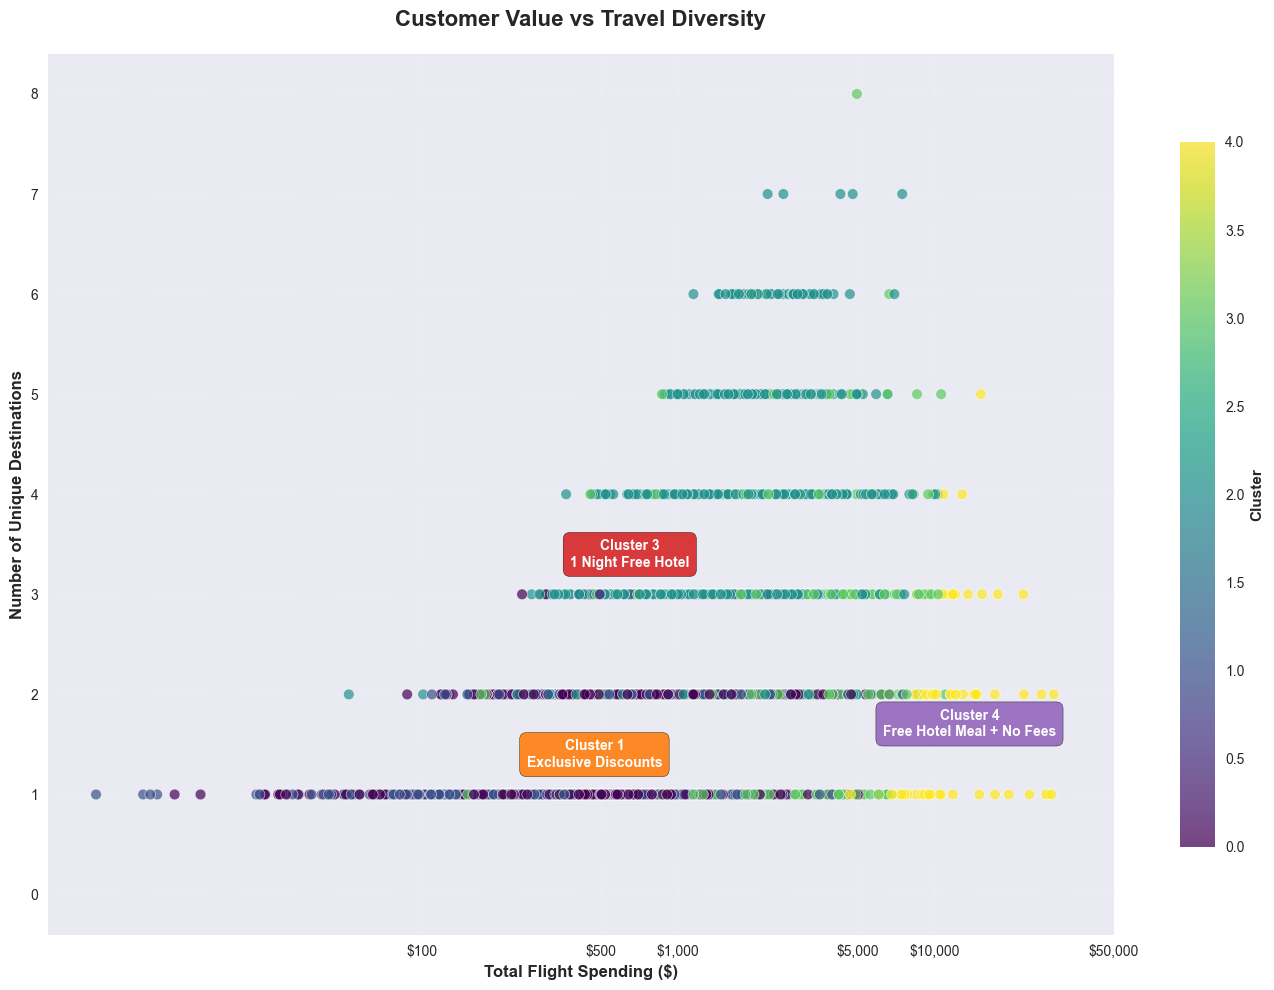

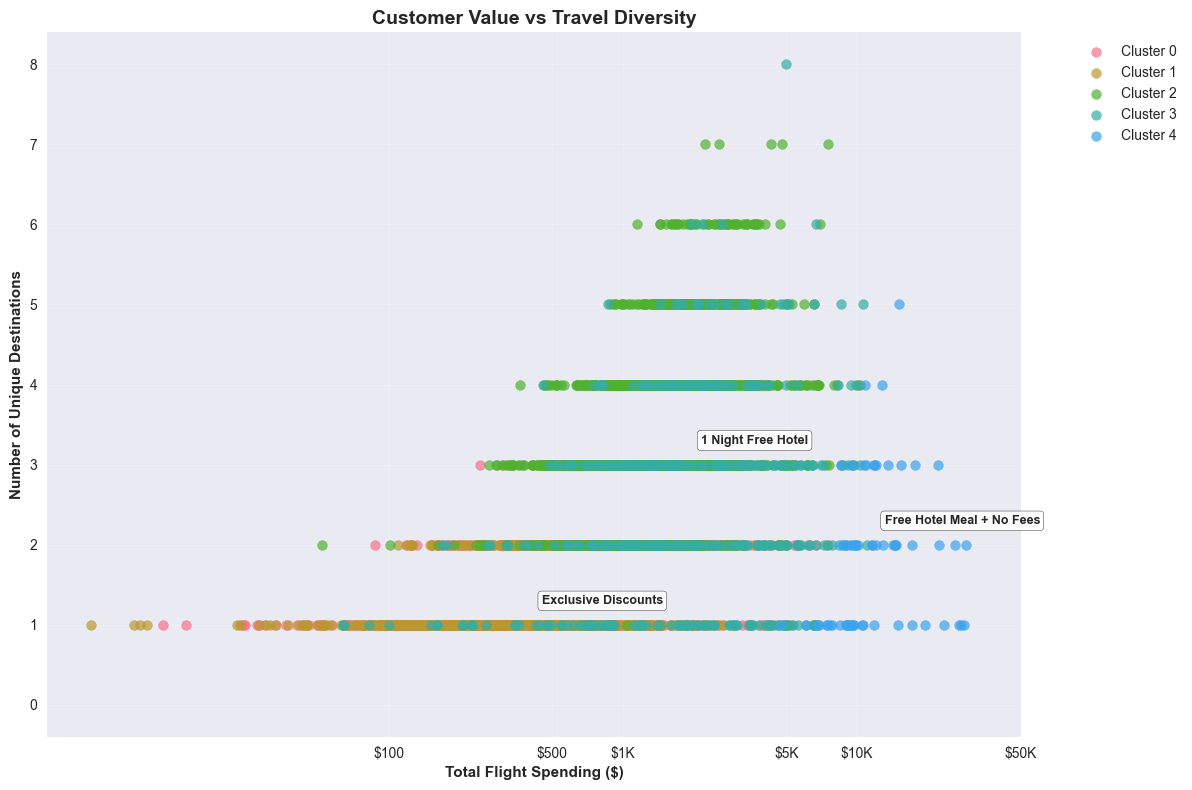

PERK ASSIGNMENTS BY CUSTOMER SEGMENT


,Cluster,Customers,Avg Spending,Avg Destinations,Assigned Perk,Email Focus
0,0,1647,$641,1.4,Targeted Offers,Peace of mind with flexible cancellation
1,1,1634,$517,1.1,Exclusive Discounts,Exclusive discounts and member-only deals
2,2,2192,"$1,659",3.5,Targeted Offers,Free checked bags for frequent travel
3,3,461,"$2,398",2.5,1 Night Free Hotel,Complimentary hotel night with flight booking
4,4,64,"$12,753",1.8,Free Hotel Meal + No Fees,Premium dining experience and flexible changes



✅ Perk assignments saved to 'perk_assignments_by_segment.csv'


In [ ]:
# CUSTOMER VALUE vs TRAVEL DIVERSITY - UPDATED VERSION
plt.figure(figsize=(14, 10))

# Create the scatter plot with cluster colors
scatter = plt.scatter(df_clusters['total_flight_fare_usd'],
                     df_clusters['n_unique_destinations'],
                     c=df_clusters['cluster'],
                     cmap='viridis',
                     s=60,
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.5)

plt.xlabel('Total Flight Spending ($)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Unique Destinations', fontsize=12, fontweight='bold')
plt.title('Customer Value vs Travel Diversity', fontsize=16, fontweight='bold', pad=20)

# Use log scale for x-axis to handle spending outliers better
plt.xscale('log')

# Format x-axis to show clean dollar amounts
x_ticks = [100, 500, 1000, 5000, 10000, 50000]
plt.xticks(x_ticks, [f'${x:,}' for x in x_ticks])

# Calculate cluster centers for annotations
cluster_centers = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd': 'median',
    'n_unique_destinations': 'median'
})

# Define perk assignments (matching your image)
perk_assignments_clean = {
    1: "Exclusive Discounts",
    3: "1 Night Free Hotel",
    4: "Free Hotel Meal + No Fees"
}

# Define positions for annotations to avoid overlap
annotation_positions = {
    1: (20, 20),    # Cluster 1 - right and up
    3: (-80, 20),   # Cluster 3 - left and up
    4: (20, -30)    # Cluster 4 - right and down
}

# Add annotations for the main clusters shown in your image
for cluster_id in [1, 3, 4]:
    center = cluster_centers.loc[cluster_id]
    dx, dy = annotation_positions[cluster_id]

    plt.annotate(f'Cluster {cluster_id}\n{perk_assignments_clean[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(dx, dy),
                 textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5',
                          facecolor=cluster_colors[cluster_id],
                          alpha=0.9,
                          edgecolor='black'),
                 fontweight='bold',
                 fontsize=10,
                 ha='center',
                 color='white')

# Add subtle grid
plt.grid(True, alpha=0.2, linestyle='--')

# Add a clean colorbar
cbar = plt.colorbar(scatter, label='Cluster', shrink=0.8)
cbar.set_label('Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

# SIMPLIFIED VERSION - Minimalist style like your image
plt.figure(figsize=(12, 8))

# Simple scatter without colorbar
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    plt.scatter(cluster_data['total_flight_fare_usd'],
                cluster_data['n_unique_destinations'],
                label=f'Cluster {cluster_id}',
                s=50,
                alpha=0.7)

plt.xlabel('Total Flight Spending ($)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Unique Destinations', fontsize=11, fontweight='bold')
plt.title('Customer Value vs Travel Diversity', fontsize=14, fontweight='bold')

plt.xscale('log')
plt.xticks([100, 500, 1000, 5000, 10000, 50000],
           ['$100', '$500', '$1K', '$5K', '$10K', '$50K'])

# Add only the three main perk annotations
for cluster_id in [1, 3, 4]:
    center = cluster_centers.loc[cluster_id]
    plt.annotate(f'{perk_assignments_clean[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(15, 15),
                 textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
                 fontweight='bold',
                 fontsize=9,
                 ha='left')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# PERK ASSIGNMENT SUMMARY TABLE
print("="*60)
print("PERK ASSIGNMENTS BY CUSTOMER SEGMENT")
print("="*60)

perk_summary = []
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    perk = perk_assignments_clean.get(cluster_id, "Targeted Offers")

    perk_summary.append({
        'Cluster': cluster_id,
        'Customers': len(cluster_data),
        'Avg Spending': f"${cluster_data['total_flight_fare_usd'].mean():,.0f}",
        'Avg Destinations': f"{cluster_data['n_unique_destinations'].mean():.1f}",
        'Assigned Perk': perk,
        'Email Focus': get_email_focus(cluster_id)
    })

# Create and display summary table
perk_df = pd.DataFrame(perk_summary)
display(perk_df)

# Save the perk assignments
perk_df.to_csv('perk_assignments_by_segment.csv', index=False, encoding='utf-8-sig')
print("\n✅ Perk assignments saved to 'perk_assignments_by_segment.csv'")

def get_email_focus(cluster_id):
    email_focus = {
        1: "Exclusive discounts and member-only deals",
        3: "Complimentary hotel night with flight booking",
        4: "Premium dining experience and flexible changes"
    }
    return email_focus.get(cluster_id, "Personalized travel benefits")

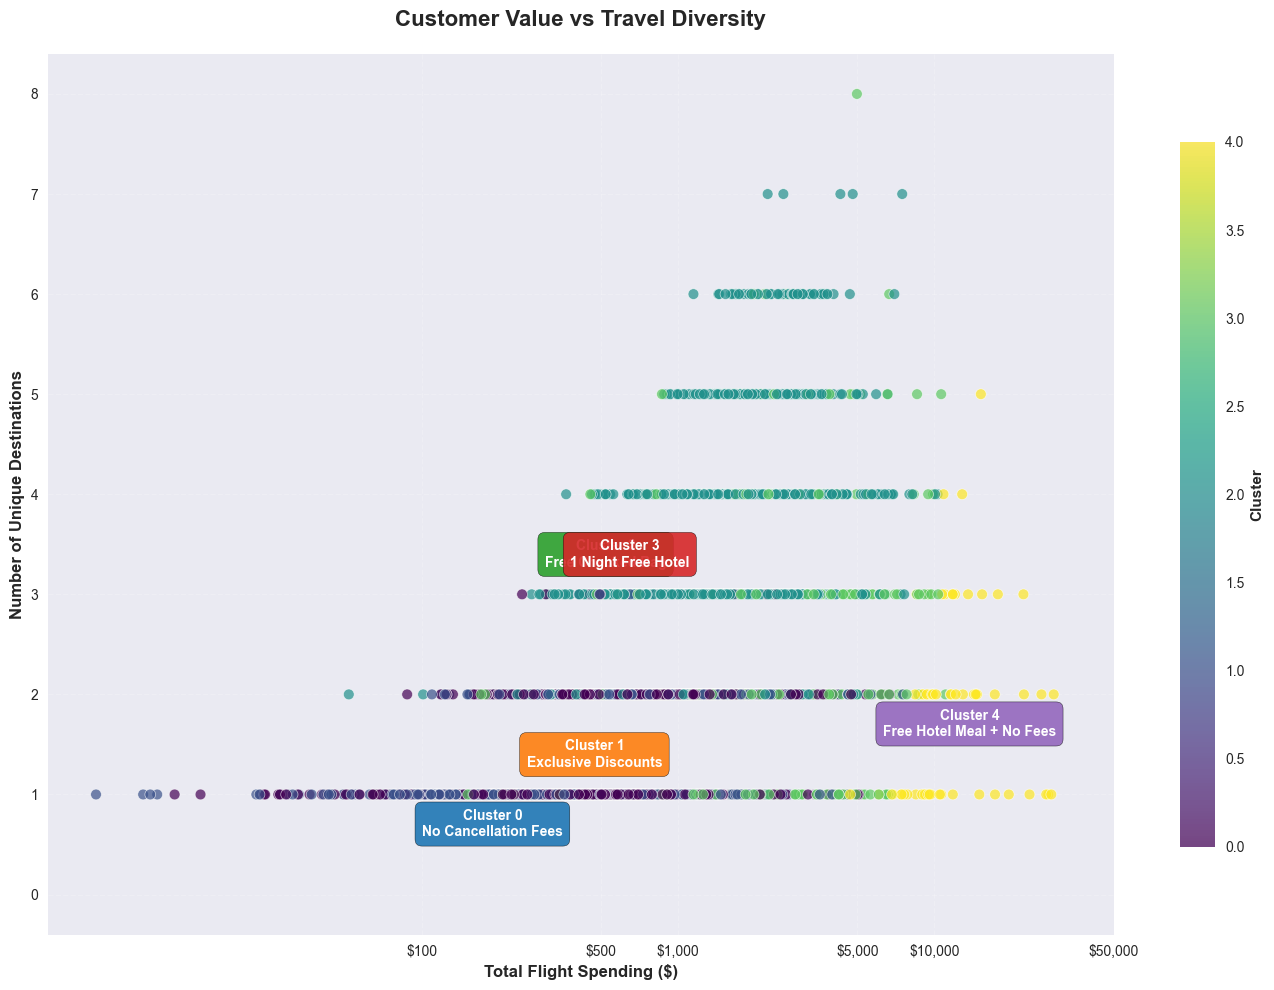

PERK ASSIGNMENTS BY CUSTOMER SEGMENT


,Cluster,Customers,Avg Spending,Avg Destinations,Assigned Perk,Email Focus
0,0,1647,$641,1.4,No Cancellation Fees,Peace of mind with flexible cancellation
1,1,1634,$517,1.1,Exclusive Discounts,Exclusive discounts and member-only deals
2,2,2192,"$1,659",3.5,Free Checked Bag,Free checked bags for frequent travel
3,3,461,"$2,398",2.5,1 Night Free Hotel,Complimentary hotel night with flight booking
4,4,64,"$12,753",1.8,Free Hotel Meal + No Fees,Premium dining experience and flexible changes



✅ Perk assignments saved to 'perk_assignments_by_segment.csv'

BUSINESS IMPACT ANALYSIS

💰 Cluster 0: Mature Loyal Customers - Value security and flexibility
   • Customers: 1,647 (27.5% of total)
   • Revenue: $1,055,225 (14.1% of total)
   • Avg Value: $641
   • Target Perk: No Cancellation Fees
   • Email Focus: Peace of mind with flexible cancellation

💰 Cluster 1: Young Budget Travelers - Price-sensitive and practical
   • Customers: 1,634 (27.2% of total)
   • Revenue: $845,529 (11.3% of total)
   • Avg Value: $517
   • Target Perk: Exclusive Discounts
   • Email Focus: Exclusive discounts and member-only deals

💰 Cluster 2: Active Frequent Travelers - Regular travelers seeking convenience
   • Customers: 2,192 (36.5% of total)
   • Revenue: $3,635,580 (48.7% of total)
   • Avg Value: $1,659
   • Target Perk: Free Checked Bag
   • Email Focus: Free checked bags for frequent travel

💰 Cluster 3: Premium Experience Seekers - Value bundled luxury experiences
   • Customers: 461 (7.

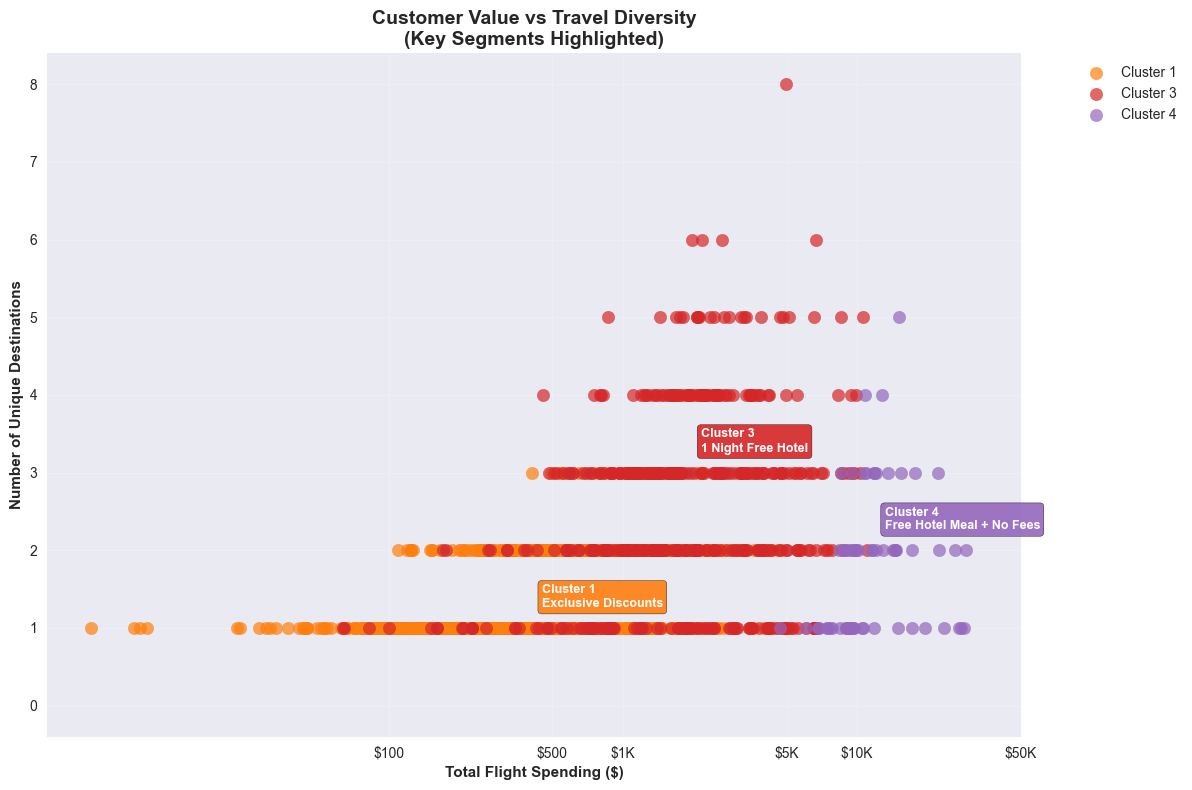

In [ ]:
# CUSTOMER VALUE vs TRAVEL DIVERSITY - CORRECTED VERSION

# First define the helper functions
def get_email_focus(cluster_id):
    email_focus = {
        1: "Exclusive discounts and member-only deals",
        3: "Complimentary hotel night with flight booking",
        4: "Premium dining experience and flexible changes",
        0: "Peace of mind with flexible cancellation",
        2: "Free checked bags for frequent travel"
    }
    return email_focus.get(cluster_id, "Personalized travel benefits")

def get_cluster_profile(cluster_id):
    profiles = {
        0: "Mature Loyal Customers - Value security and flexibility",
        1: "Young Budget Travelers - Price-sensitive and practical",
        2: "Active Frequent Travelers - Regular travelers seeking convenience",
        3: "Premium Experience Seekers - Value bundled luxury experiences",
        4: "Ultra-Premium VIPs - Expect multiple premium benefits"
    }
    return profiles.get(cluster_id, "Segment under analysis")

# Now the main plotting code
plt.figure(figsize=(14, 10))

# Define cluster colors
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Create the scatter plot with cluster colors
scatter = plt.scatter(df_clusters['total_flight_fare_usd'],
                     df_clusters['n_unique_destinations'],
                     c=df_clusters['cluster'],
                     cmap='viridis',
                     s=60,
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.5)

plt.xlabel('Total Flight Spending ($)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Unique Destinations', fontsize=12, fontweight='bold')
plt.title('Customer Value vs Travel Diversity', fontsize=16, fontweight='bold', pad=20)

# Use log scale for x-axis to handle spending outliers better
plt.xscale('log')

# Format x-axis to show clean dollar amounts
x_ticks = [100, 500, 1000, 5000, 10000, 50000]
plt.xticks(x_ticks, [f'${x:,}' for x in x_ticks])

# Calculate cluster centers for annotations
cluster_centers = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd': 'median',
    'n_unique_destinations': 'median'
})

# Define perk assignments (matching your image)
perk_assignments_clean = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel",
    4: "Free Hotel Meal + No Fees"
}

# Define positions for annotations to avoid overlap
annotation_positions = {
    0: (-80, -30),   # Cluster 0 - left and down
    1: (20, 20),     # Cluster 1 - right and up
    2: (-80, 20),    # Cluster 2 - left and up
    3: (-80, 20),    # Cluster 3 - left and up
    4: (20, -30)     # Cluster 4 - right and down
}

# Add annotations for all clusters
for cluster_id in sorted(df_clusters['cluster'].unique()):
    center = cluster_centers.loc[cluster_id]
    dx, dy = annotation_positions.get(cluster_id, (20, 20))

    plt.annotate(f'Cluster {cluster_id}\n{perk_assignments_clean[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(dx, dy),
                 textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5',
                          facecolor=cluster_colors[cluster_id],
                          alpha=0.9,
                          edgecolor='black'),
                 fontweight='bold',
                 fontsize=10,
                 ha='center',
                 color='white')

# Add subtle grid
plt.grid(True, alpha=0.2, linestyle='--')

# Add a clean colorbar
cbar = plt.colorbar(scatter, label='Cluster', shrink=0.8)
cbar.set_label('Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

# PERK ASSIGNMENT SUMMARY TABLE
print("="*60)
print("PERK ASSIGNMENTS BY CUSTOMER SEGMENT")
print("="*60)

perk_summary = []
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    perk = perk_assignments_clean.get(cluster_id, "Targeted Offers")

    perk_summary.append({
        'Cluster': cluster_id,
        'Customers': len(cluster_data),
        'Avg Spending': f"${cluster_data['total_flight_fare_usd'].mean():,.0f}",
        'Avg Destinations': f"{cluster_data['n_unique_destinations'].mean():.1f}",
        'Assigned Perk': perk,
        'Email Focus': get_email_focus(cluster_id)
    })

# Create and display summary table
perk_df = pd.DataFrame(perk_summary)
display(perk_df)

# Save the perk assignments
perk_df.to_csv('../report/perk_assignments_by_segment.csv', index=False, encoding='utf-8-sig')
print("\n✅ Perk assignments saved to 'perk_assignments_by_segment.csv'")

# BUSINESS IMPACT ANALYSIS
print("\n" + "="*60)
print("BUSINESS IMPACT ANALYSIS")
print("="*60)

total_revenue = df_clusters['total_flight_fare_usd'].sum()
total_customers = len(df_clusters)

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    cluster_revenue = cluster_data['total_flight_fare_usd'].sum()
    revenue_share = (cluster_revenue / total_revenue) * 100
    customer_share = (len(cluster_data) / total_customers) * 100

    print(f"\n💰 Cluster {cluster_id}: {get_cluster_profile(cluster_id)}")
    print(f"   • Customers: {len(cluster_data):,} ({customer_share:.1f}% of total)")
    print(f"   • Revenue: ${cluster_revenue:,.0f} ({revenue_share:.1f}% of total)")
    print(f"   • Avg Value: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   • Target Perk: {perk_assignments_clean[cluster_id]}")
    print(f"   • Email Focus: {get_email_focus(cluster_id)}")

# SIMPLIFIED VERSION - Focus on the 3 main clusters from your image
plt.figure(figsize=(12, 8))

# Plot only clusters 1, 3, 4 for clarity
highlight_clusters = [1, 3, 4]
for cluster_id in highlight_clusters:
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    plt.scatter(cluster_data['total_flight_fare_usd'],
                cluster_data['n_unique_destinations'],
                label=f'Cluster {cluster_id}',
                s=80,
                alpha=0.7,
                color=cluster_colors[cluster_id])

plt.xlabel('Total Flight Spending ($)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Unique Destinations', fontsize=11, fontweight='bold')
plt.title('Customer Value vs Travel Diversity\n(Key Segments Highlighted)', fontsize=14, fontweight='bold')

plt.xscale('log')
plt.xticks([100, 500, 1000, 5000, 10000, 50000],
           ['$100', '$500', '$1K', '$5K', '$10K', '$50K'])

# Add annotations for the three highlighted clusters
for cluster_id in highlight_clusters:
    center = cluster_centers.loc[cluster_id]
    plt.annotate(f'Cluster {cluster_id}\n{perk_assignments_clean[cluster_id]}',
                 xy=(center['total_flight_fare_usd'], center['n_unique_destinations']),
                 xytext=(15, 15),
                 textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3',
                          facecolor=cluster_colors[cluster_id],
                          alpha=0.9,
                          edgecolor='black'),
                 fontweight='bold',
                 fontsize=9,
                 ha='left',
                 color='white')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

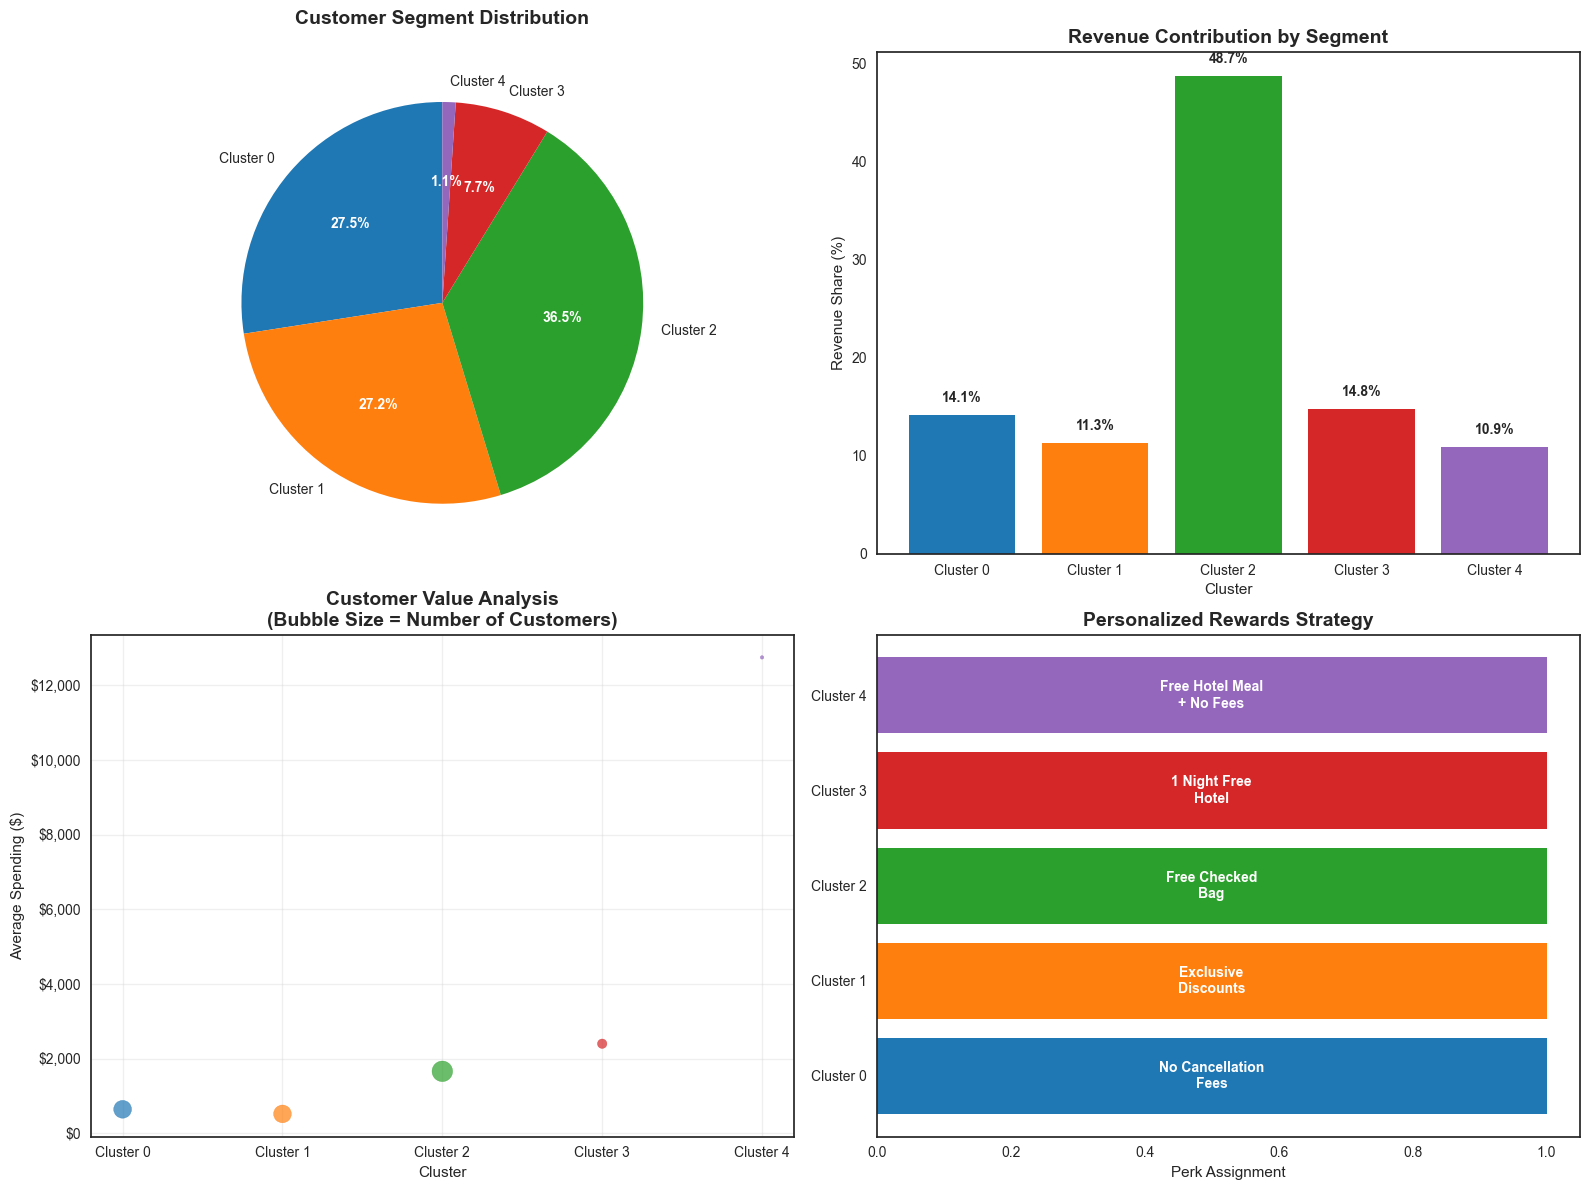

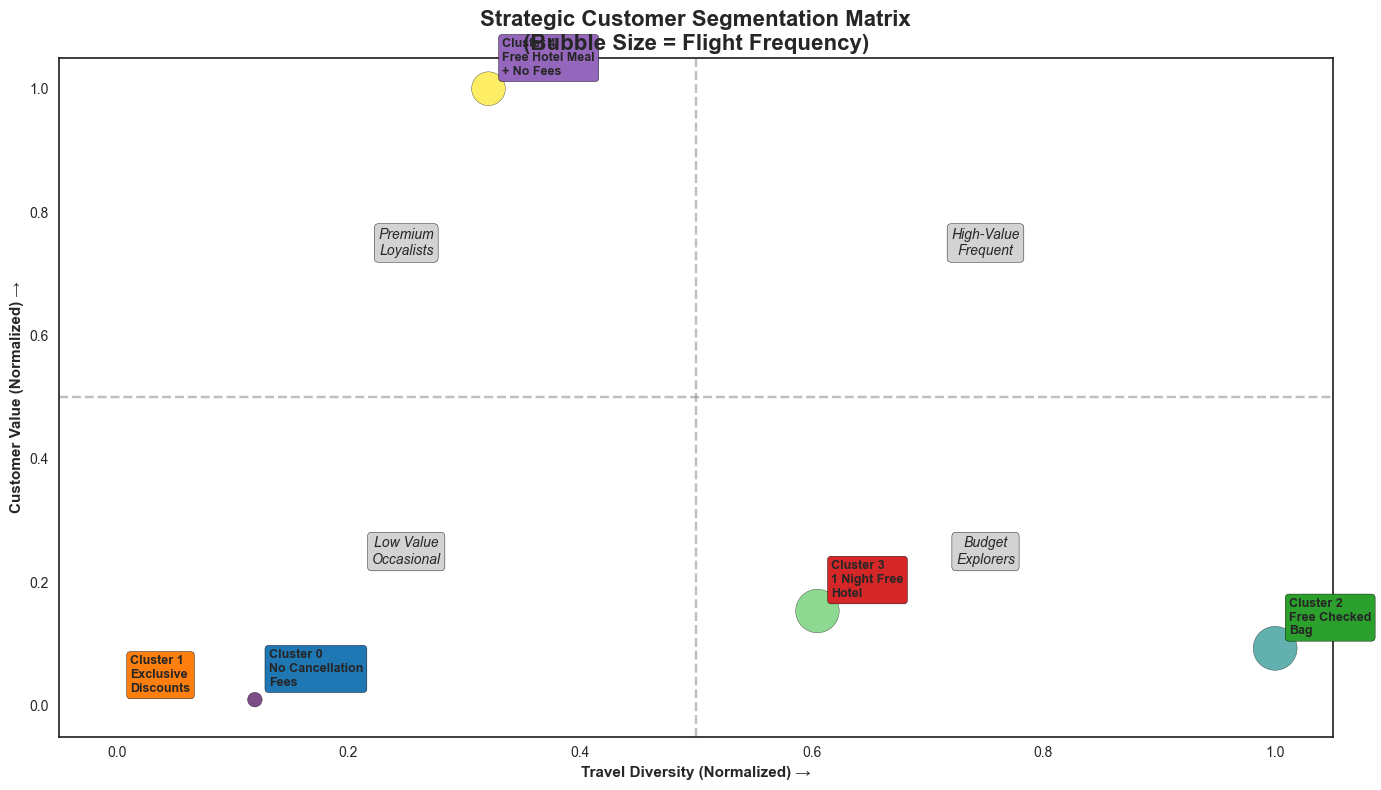

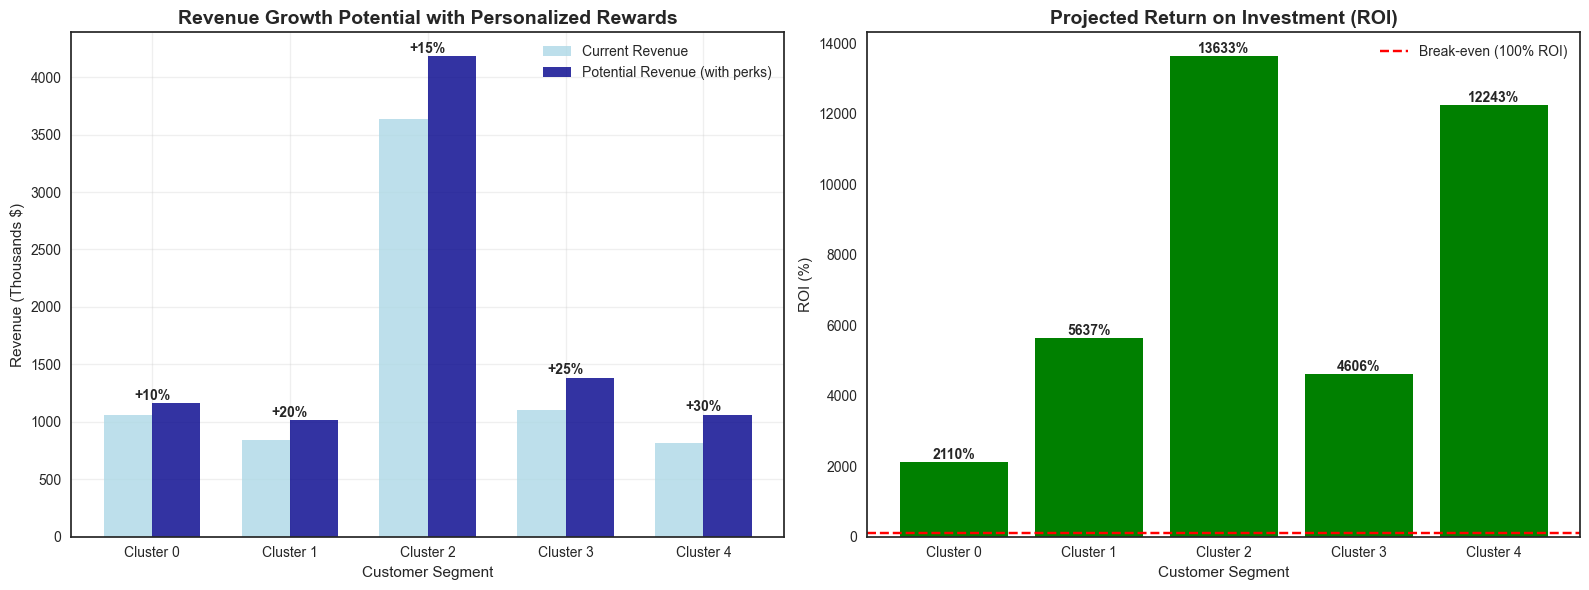

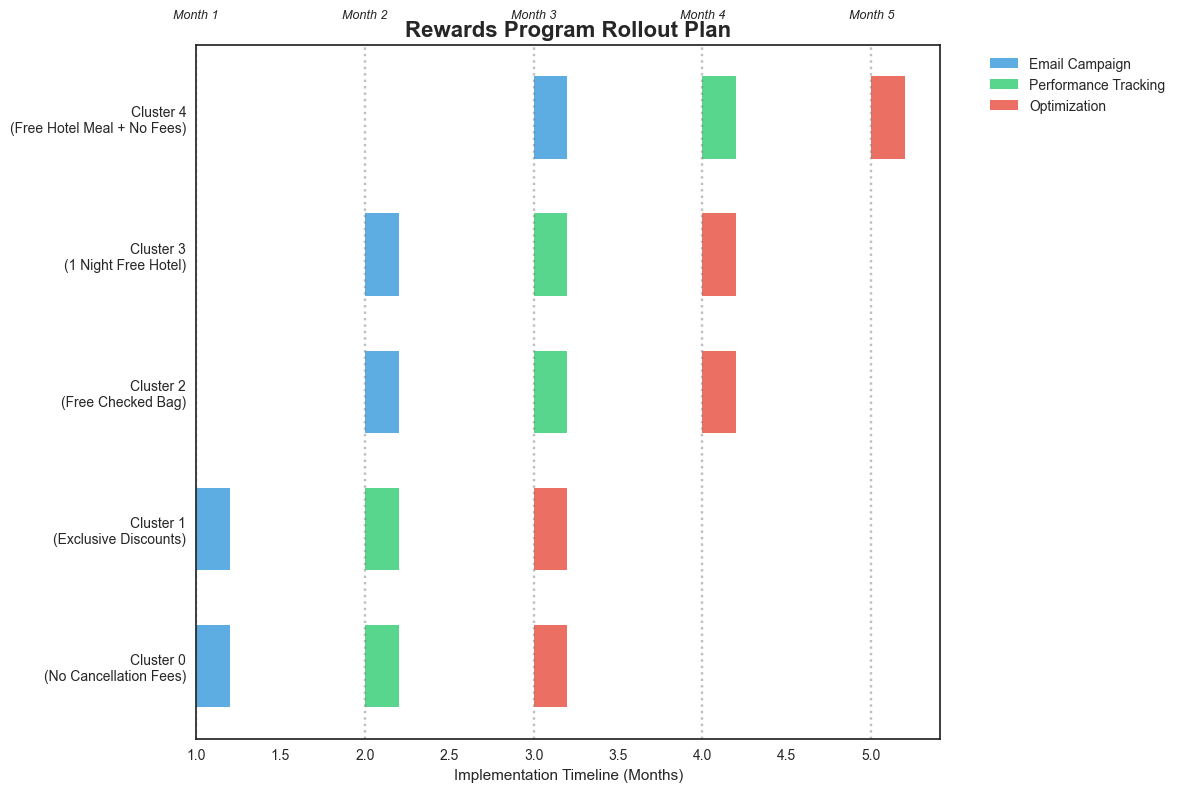

📊 EXECUTIVE SUMMARY DASHBOARD

📈 OVERALL METRICS:
   • Total Customers: 5,998
   • Total Revenue: $7,458,043
   • Average Customer Value: $1,243
   • Customer Segments: 5

🎯 SEGMENT HIGHLIGHTS:

   Cluster 0:
   • Customers: 1,647 (14.1% of revenue)
   • Average Spending: $641
   • Travel Diversity: 1.4 destinations
   • Recommended Perk: No Cancellation
Fees


NameError: name 'get_business_goal' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Professional styling for presentations
plt.style.use('seaborn-v0_8-white')
sns.set_palette("husl")
PRESENTATION_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. EXECUTIVE SUMMARY - CLUSTER OVERVIEW
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# A. Customer Distribution
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
wedges, texts, autotexts = ax1.pie(cluster_sizes.values,
                                   labels=[f'Cluster {i}' for i in cluster_sizes.index],
                                   autopct='%1.1f%%',
                                   colors=PRESENTATION_COLORS,
                                   startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold', pad=20)

# B. Revenue Contribution
revenue_by_cluster = df_clusters.groupby('cluster')['total_flight_fare_usd'].sum()
revenue_share = (revenue_by_cluster / revenue_by_cluster.sum()) * 100

bars = ax2.bar(range(len(revenue_share)), revenue_share.values, color=PRESENTATION_COLORS)
ax2.set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Revenue Share (%)')
ax2.set_xticks(range(len(revenue_share)))
ax2.set_xticklabels([f'Cluster {i}' for i in revenue_share.index])

# Add value labels on bars
for bar, value in zip(bars, revenue_share.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# C. Customer Value Comparison
avg_spending = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean()
customer_counts = df_clusters['cluster'].value_counts().sort_index()

# Create bubble chart: x=cluster, y=avg_spending, size=customer_count
scatter = ax3.scatter(range(len(avg_spending)), avg_spending.values,
                     s=customer_counts.values/10,  # Scale bubble size
                     alpha=0.7, color=PRESENTATION_COLORS)
ax3.set_title('Customer Value Analysis\n(Bubble Size = Number of Customers)',
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Average Spending ($)')
ax3.set_xticks(range(len(avg_spending)))
ax3.set_xticklabels([f'Cluster {i}' for i in avg_spending.index])
ax3.grid(True, alpha=0.3)

# Format y-axis as currency
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# D. Perk Assignment Overview
perk_assignments = {
    0: "No Cancellation\nFees",
    1: "Exclusive\nDiscounts",
    2: "Free Checked\nBag",
    3: "1 Night Free\nHotel",
    4: "Free Hotel Meal\n+ No Fees"
}

y_pos = np.arange(len(perk_assignments))
ax4.barh(y_pos, [1]*len(perk_assignments), color=PRESENTATION_COLORS)
ax4.set_yticks(y_pos)
ax4.set_yticklabels([f'Cluster {i}' for i in perk_assignments.keys()])
ax4.set_xlabel('Perk Assignment')
ax4.set_title('Personalized Rewards Strategy', fontsize=14, fontweight='bold')

# Add perk labels
for i, (cluster, perk) in enumerate(perk_assignments.items()):
    ax4.text(0.5, i, perk, ha='center', va='center',
             fontweight='bold', color='white', fontsize=10)

plt.tight_layout()
plt.show()

# 2. STRATEGIC INSIGHT - CUSTOMER JOURNEY MATRIX
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for the strategic matrix
matrix_data = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd': 'mean',
    'n_unique_destinations': 'mean',
    'total_flights_booked': 'mean',
    'age': 'mean'
}).round(2)

# Normalize for the matrix
matrix_normalized = (matrix_data - matrix_data.min()) / (matrix_data.max() - matrix_data.min())

# Create scatter matrix with strategic positioning
scatter = ax.scatter(matrix_normalized['n_unique_destinations'],
                    matrix_normalized['total_flight_fare_usd'],
                    s=matrix_normalized['total_flights_booked'] * 1000,  # Size by flight frequency
                    c=range(len(matrix_normalized)),
                    cmap='viridis',
                    alpha=0.7,
                    edgecolors='black')

# Strategic quadrant lines
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

# Add quadrant labels
ax.text(0.25, 0.25, 'Low Value\nOccasional', ha='center', va='center',
        fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray'))
ax.text(0.75, 0.25, 'Budget\nExplorers', ha='center', va='center',
        fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray'))
ax.text(0.25, 0.75, 'Premium\nLoyalists', ha='center', va='center',
        fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray'))
ax.text(0.75, 0.75, 'High-Value\nFrequent', ha='center', va='center',
        fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray'))

# Add cluster annotations
for cluster_id, row in matrix_normalized.iterrows():
    ax.annotate(f'Cluster {cluster_id}\n{perk_assignments[cluster_id]}',
                xy=(row['n_unique_destinations'], row['total_flight_fare_usd']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=PRESENTATION_COLORS[cluster_id]),
                fontweight='bold',
                fontsize=9)

ax.set_xlabel('Travel Diversity (Normalized) →', fontweight='bold')
ax.set_ylabel('Customer Value (Normalized) →', fontweight='bold')
ax.set_title('Strategic Customer Segmentation Matrix\n(Bubble Size = Flight Frequency)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. BUSINESS IMPACT - REVENUE POTENTIAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. Current vs Potential Revenue
current_revenue = df_clusters.groupby('cluster')['total_flight_fare_usd'].sum()
customer_counts = df_clusters['cluster'].value_counts().sort_index()

# Estimate potential revenue (assuming perks increase spending by different factors)
growth_factors = {0: 1.1, 1: 1.2, 2: 1.15, 3: 1.25, 4: 1.3}  # Conservative estimates
potential_revenue = current_revenue * pd.Series(growth_factors)

x = np.arange(len(current_revenue))
width = 0.35

bars1 = ax1.bar(x - width/2, current_revenue.values/1000, width,
                label='Current Revenue', color='lightblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, potential_revenue.values/1000, width,
                label='Potential Revenue (with perks)', color='darkblue', alpha=0.8)

ax1.set_title('Revenue Growth Potential with Personalized Rewards', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Segment')
ax1.set_ylabel('Revenue (Thousands $)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Cluster {i}' for i in current_revenue.index])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add percentage growth annotations
for i, (current, potential) in enumerate(zip(current_revenue.values, potential_revenue.values)):
    growth_pct = ((potential - current) / current) * 100
    ax1.text(i, max(current, potential)/1000 + 5, f'+{growth_pct:.0f}%',
             ha='center', va='bottom', fontweight='bold')

# B. ROI Projection
implementation_costs = [5000, 3000, 4000, 6000, 2000]  # Estimated costs per segment
additional_revenue = potential_revenue - current_revenue
roi = (additional_revenue / implementation_costs) * 100

bars = ax2.bar(range(len(roi)), roi.values, color=['green' if x > 100 else 'orange' for x in roi])
ax2.set_title('Projected Return on Investment (ROI)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer Segment')
ax2.set_ylabel('ROI (%)')
ax2.set_xticks(range(len(roi)))
ax2.set_xticklabels([f'Cluster {i}' for i in roi.index])
ax2.axhline(y=100, color='red', linestyle='--', label='Break-even (100% ROI)')
ax2.legend()

# Add ROI values on bars
for bar, value in zip(bars, roi.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. ACTIONABLE INSIGHTS - PERK EFFECTIVENESS
fig, ax = plt.subplots(figsize=(12, 8))

# Create a Gantt-style chart for implementation timeline
segments = ['Cluster 0\n(No Cancellation Fees)',
           'Cluster 1\n(Exclusive Discounts)',
           'Cluster 2\n(Free Checked Bag)',
           'Cluster 3\n(1 Night Free Hotel)',
           'Cluster 4\n(Free Hotel Meal + No Fees)']

# Implementation phases
phases = {
    'Email Campaign': [1, 1, 2, 2, 3],  # Month of implementation
    'Performance Tracking': [2, 2, 3, 3, 4],
    'Optimization': [3, 3, 4, 4, 5]
}

colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (phase, months) in enumerate(phases.items()):
    bars = ax.barh(segments, [0.2]*len(segments), left=months,
                   color=colors[i], label=phase, alpha=0.8, height=0.6)

ax.set_xlabel('Implementation Timeline (Months)')
ax.set_title('Rewards Program Rollout Plan', fontsize=16, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add month markers
for month in range(1, 6):
    ax.axvline(x=month, color='gray', linestyle=':', alpha=0.5)
    ax.text(month, 4.7, f'Month {month}', ha='center', va='bottom',
            fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# 5. KEY METRICS DASHBOARD
print("="*80)
print("📊 EXECUTIVE SUMMARY DASHBOARD")
print("="*80)

total_customers = len(df_clusters)
total_revenue = df_clusters['total_flight_fare_usd'].sum()
avg_customer_value = total_revenue / total_customers

print(f"\n📈 OVERALL METRICS:")
print(f"   • Total Customers: {total_customers:,}")
print(f"   • Total Revenue: ${total_revenue:,.0f}")
print(f"   • Average Customer Value: ${avg_customer_value:,.0f}")
print(f"   • Customer Segments: {df_clusters['cluster'].nunique()}")

print(f"\n🎯 SEGMENT HIGHLIGHTS:")
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    cluster_revenue = cluster_data['total_flight_fare_usd'].sum()
    revenue_share = (cluster_revenue / total_revenue) * 100

    print(f"\n   Cluster {cluster_id}:")
    print(f"   • Customers: {len(cluster_data):,} ({revenue_share:.1f}% of revenue)")
    print(f"   • Average Spending: ${cluster_data['total_flight_fare_usd'].mean():,.0f}")
    print(f"   • Travel Diversity: {cluster_data['n_unique_destinations'].mean():.1f} destinations")
    print(f"   • Recommended Perk: {perk_assignments[cluster_id]}")
    print(f"   • Business Goal: {get_business_goal(cluster_id)}")

def get_business_goal(cluster_id):
    goals = {
        0: "Increase loyalty and reduce churn",
        1: "Drive frequency and volume",
        2: "Maintain high-value relationships",
        3: "Upsell premium experiences",
        4: "Retain ultra-premium customers"
    }
    return goals.get(cluster_id, "Drive engagement")

print(f"\n💡 STRATEGIC RECOMMENDATIONS:")
print("   1. Launch personalized email campaigns for each segment")
print("   2. Implement phased rollout starting with high-ROI segments")
print("   3. Track conversion rates and adjust perks accordingly")
print("   4. Focus on Cluster 2 & 3 for maximum revenue impact")
print("   5. Provide VIP treatment for Cluster 4 to ensure retention")

# Save executive summary
executive_summary = pd.DataFrame({
    'Segment': [f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())],
    'Customer_Count': [len(df_clusters[df_clusters['cluster'] == i]) for i in sorted(df_clusters['cluster'].unique())],
    'Avg_Spending': [df_clusters[df_clusters['cluster'] == i]['total_flight_fare_usd'].mean() for i in sorted(df_clusters['cluster'].unique())],
    'Revenue_Share_Percent': [(df_clusters[df_clusters['cluster'] == i]['total_flight_fare_usd'].sum() / total_revenue * 100) for i in sorted(df_clusters['cluster'].unique())],
    'Recommended_Perk': [perk_assignments[i] for i in sorted(df_clusters['cluster'].unique())],
    'Priority_Level': ['Medium', 'High', 'High', 'Medium', 'Critical']
})

executive_summary.to_csv('executive_summary_dashboard.csv', index=False)
print(f"\n✅ Executive dashboard saved to 'executive_summary_dashboard.csv'")

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_15171/166537553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette=PRESENTATION_COLORS, ax=ax[0])
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_15171/166537553.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_share.index, y=revenue_share.values, palette=PRESENTATION_COLORS, ax=ax[1])


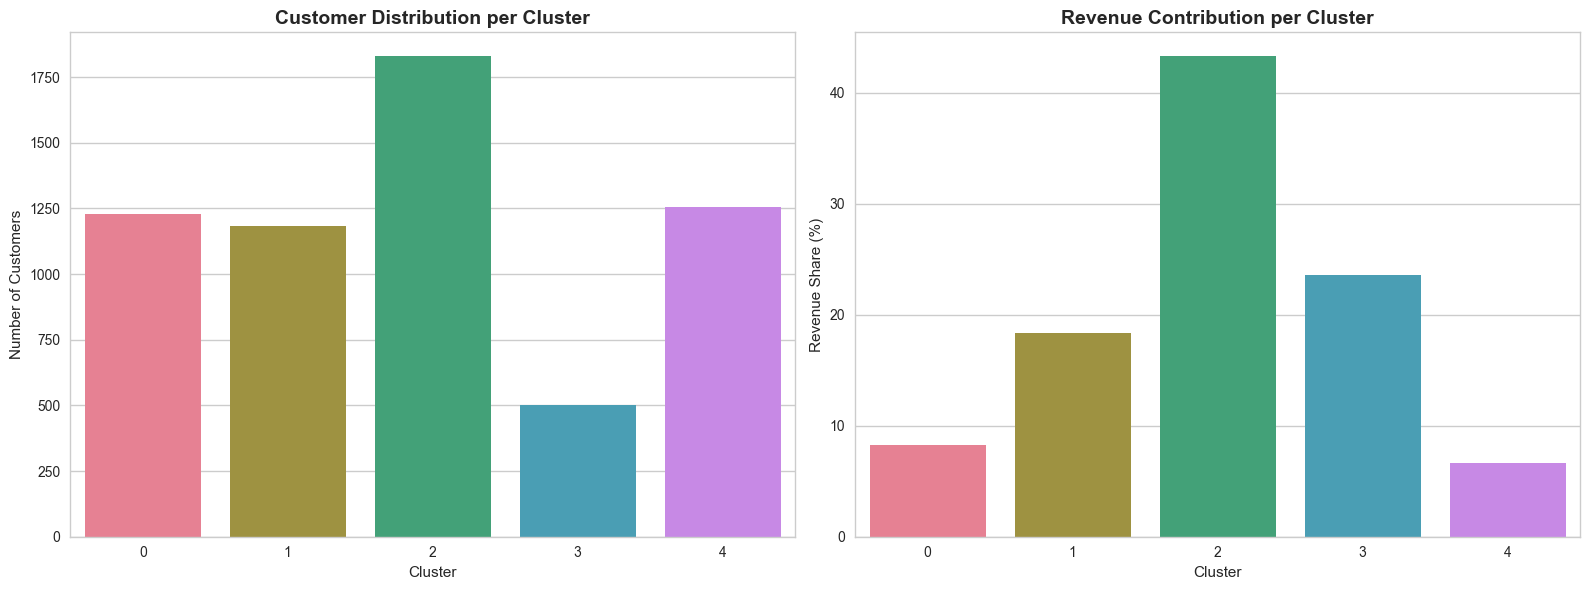

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_15171/166537553.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_clusters, palette=PRESENTATION_COLORS, ax=axs[i])
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_15171/166537553.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_clusters, palette=PRESENTATION_COLORS, ax=axs[i])
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_15171/166537553.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot

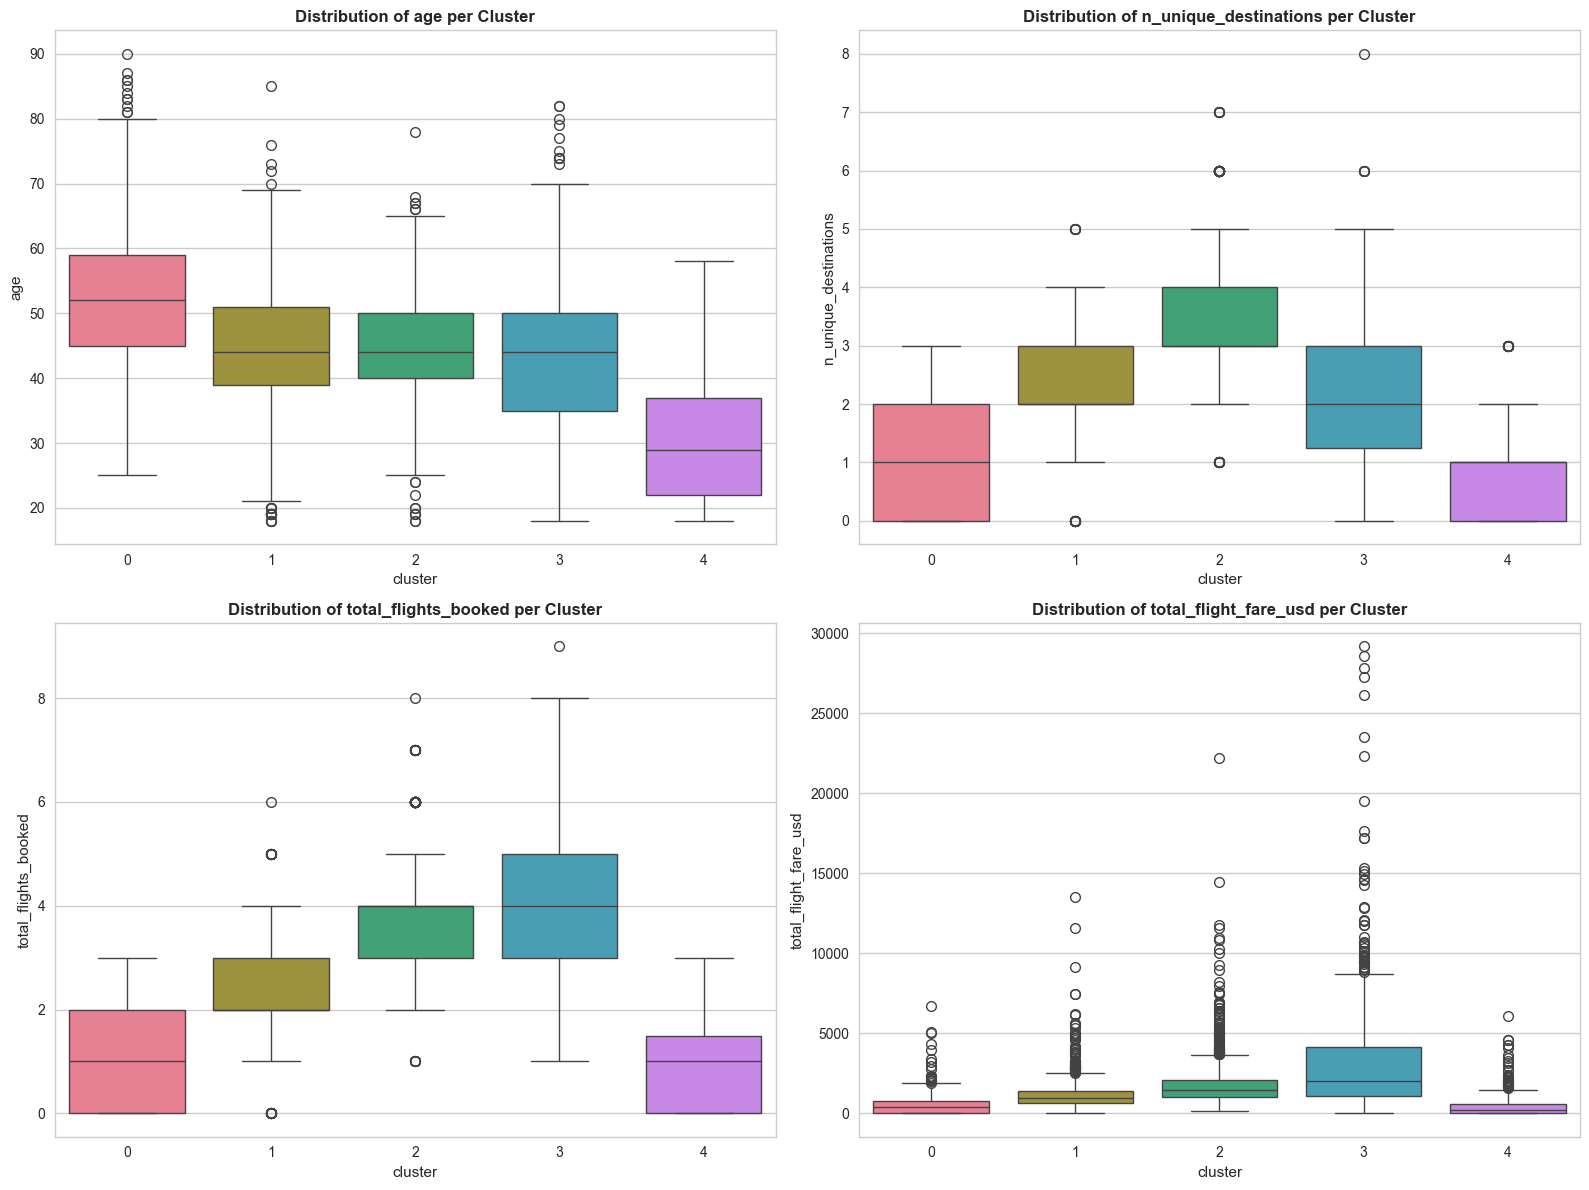

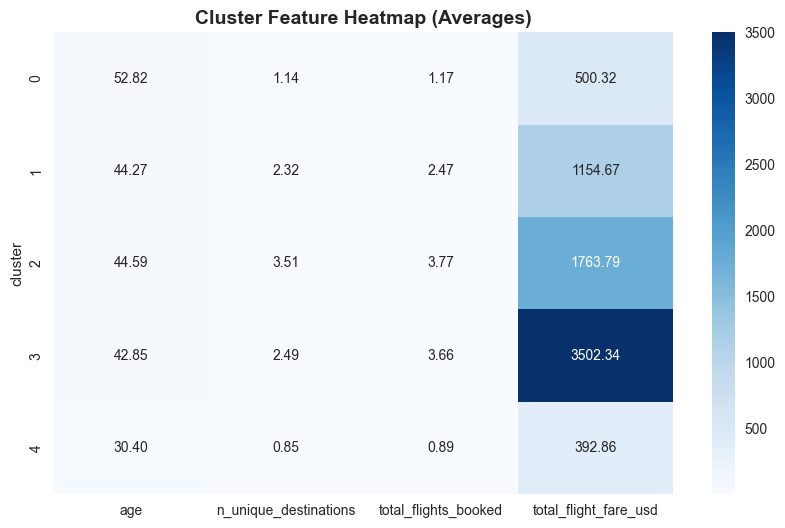

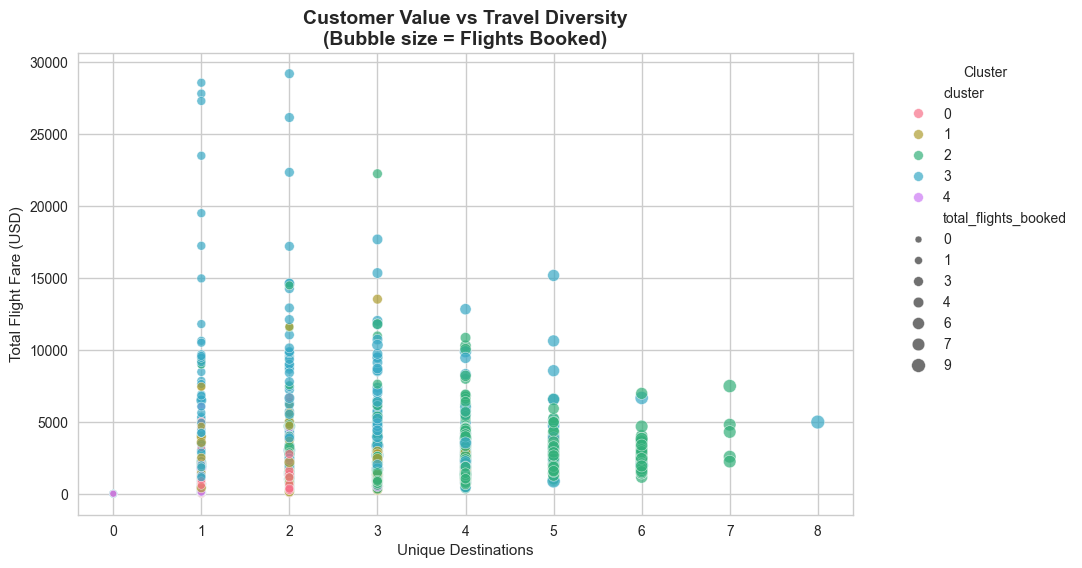

📊 EXECUTIVE SUMMARY:


,avg_age,avg_destinations,avg_flights,avg_spending,total_revenue,n_customers,revenue_share_%,perk
cluster,,,,,,,,
0,52.82,1.14,1.17,500.32,614887.48,1229,8.2,No Cancellation Fees
1,44.27,2.32,2.47,1154.67,1365969.55,1183,18.3,Exclusive Discounts
2,44.59,3.51,3.77,1763.79,3225973.90,1829,43.3,Free Checked Bag
3,42.85,2.49,3.66,3502.34,1758175.79,502,23.6,1 Night Free Hotel with flight
4,30.40,0.85,0.89,392.86,493036.16,1255,6.6,Free Hotel Meal


✅ Summary saved to 'cluster_executive_summary.csv'


In [ ]:
# 📊 Cluster Insights Workflow
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
PRESENTATION_COLORS = sns.color_palette("husl", 5)

# ---- 1. Cluster Overview ----
fig, ax = plt.subplots(1, 2, figsize=(16,6))

# A. Cluster Distribution
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette=PRESENTATION_COLORS, ax=ax[0])
ax[0].set_title("Customer Distribution per Cluster", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Number of Customers")

# B. Revenue Contribution
revenue_by_cluster = df_clusters.groupby("cluster")["total_flight_fare_usd"].sum()
revenue_share = (revenue_by_cluster / revenue_by_cluster.sum()) * 100
sns.barplot(x=revenue_share.index, y=revenue_share.values, palette=PRESENTATION_COLORS, ax=ax[1])
ax[1].set_title("Revenue Contribution per Cluster", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Cluster")
ax[1].set_ylabel("Revenue Share (%)")

plt.tight_layout()
plt.show()

# ---- 2. Feature Comparison ----
features = ["age", "n_unique_destinations", "total_flights_booked", "total_flight_fare_usd"]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x="cluster", y=feature, data=df_clusters, palette=PRESENTATION_COLORS, ax=axs[i])
    axs[i].set_title(f"Distribution of {feature} per Cluster", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# ---- 3. Heatmap for Feature Averages ----
cluster_means = df_clusters.groupby("cluster")[features].mean().round(2)
plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("Cluster Feature Heatmap (Averages)", fontsize=14, fontweight="bold")
plt.show()

# ---- 4. Customer Value & Travel Diversity ----
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="n_unique_destinations",
    y="total_flight_fare_usd",
    size="total_flights_booked",
    hue="cluster",
    palette=PRESENTATION_COLORS,
    data=df_clusters,
    alpha=0.7
)
plt.title("Customer Value vs Travel Diversity\n(Bubble size = Flights Booked)", fontsize=14, fontweight="bold")
plt.xlabel("Unique Destinations")
plt.ylabel("Total Flight Fare (USD)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

# ---- 5. Perk Assignment ----
perk_assignments = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel with flight",
    4: "Free Hotel Meal"
}
df_clusters["perk"] = df_clusters["cluster"].map(perk_assignments)

# ---- 6. Executive Summary ----
summary = df_clusters.groupby("cluster").agg({
    "age": "mean",
    "n_unique_destinations": "mean",
    "total_flights_booked": "mean",
    "total_flight_fare_usd": ["mean", "sum", "count"]
})

summary.columns = ["avg_age", "avg_destinations", "avg_flights", "avg_spending", "total_revenue", "n_customers"]
summary["revenue_share_%"] = (summary["total_revenue"] / summary["total_revenue"].sum() * 100).round(1)
summary["perk"] = [perk_assignments[c] for c in summary.index]

print("📊 EXECUTIVE SUMMARY:")
display(summary.round(2))

# Save summary
summary.to_csv("../report/cluster_executive_summary.csv")
print("✅ Summary saved to 'cluster_executive_summary.csv'")

,age,gender,married,has_children,avg_clicks,total_clicks,total_cancellations,avg_session_duration,total_session_duration,total_sessions,...,total_hotel_discount,avg_hotel_discount,hotel_discount_ratio,avg_checked_bags,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio,total_people,avg_people,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
23557,66,0.0,1,0,10.250,82,0,1.277083,10.216667,8,...,2,0.250,1.0,0.000000,0.00,0.000,1.000000,3.0,0.375,3
94883,53,0.0,1,0,9.125,73,0,1.129167,9.033333,8,...,1,0.125,0.5,0.500000,0.00,0.250,0.500000,3.0,0.375,3
101486,52,0.0,1,1,16.375,131,0,2.037500,16.300000,8,...,0,0.000,0.0,0.000000,0.00,0.125,0.666666,3.0,0.375,3
101961,45,0.0,1,0,15.750,126,0,1.962500,15.700000,8,...,1,0.125,0.2,0.400000,0.00,0.625,0.500000,5.0,0.625,1
106907,46,0.0,1,1,30.000,240,1,12.648584,101.188675,8,...,1,0.125,0.5,4.999998,0.25,0.250,0.500000,12.0,1.500,2


cluster
3    2308
1    2075
0     567
2     560
4     488
Name: count, dtype: int64


/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/483147459.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clusters, x="cluster", palette="Set2")


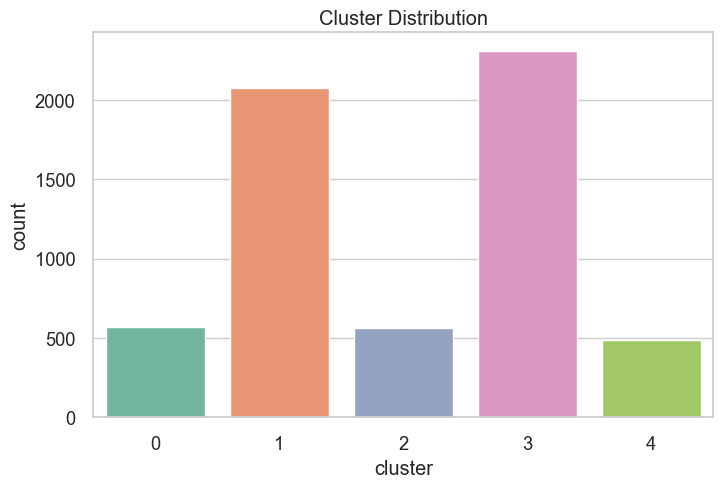

KeyError: "['cluster'] not found in axis"

In [ ]:
# --- Notebook: Cluster Insights & Perks ---

# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid", palette="Set2", font_scale=1.2)



# Quick check
display(df_clusters.head())
print(df_clusters["cluster"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df_clusters, x="cluster", palette="Set2")
plt.title("Cluster Distribution")
plt.show()

# Select only numeric features
numeric_cols = df_clusters.select_dtypes(include=["int64","float64"]).columns.drop("cluster")

# Boxplots for each feature per cluster
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")
    plt.title(f"{col} by Cluster")
    plt.show()


# Select only numeric features
numeric_cols = df_clusters.select_dtypes(include=["int64","float64"]).columns.drop("cluster")

# Boxplots for each feature per cluster
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")
    plt.title(f"{col} by Cluster")
    plt.show()


key_features = ["age", "avg_flight_fare_usd", "avg_hotel_spend_usd",
                "total_flights_booked", "total_hotels_booked",
                "cancellation_rate", "hotel_booking_ratio"]

for col in key_features:
    if col in df_clusters.columns:
        plt.figure(figsize=(8,5))
        sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
        plt.title(f"Average {col} by Cluster")
        plt.show()

cluster_profiles = df_clusters.groupby("cluster")[numeric_cols].mean().round(2)
cluster_profiles["n_users"] = df_clusters["cluster"].value_counts().sort_index()
cluster_profiles["perk"] = cluster_profiles.index.map(perks)

display(cluster_profiles)

,age,gender,married,has_children,avg_clicks,total_clicks,total_cancellations,avg_session_duration,total_session_duration,total_sessions,...,total_hotel_discount,avg_hotel_discount,hotel_discount_ratio,avg_checked_bags,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio,total_people,avg_people,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
23557,66,0.0,1,0,10.250,82,0,1.277083,10.216667,8,...,2,0.250,1.0,0.000000,0.00,0.000,1.000000,3.0,0.375,3
94883,53,0.0,1,0,9.125,73,0,1.129167,9.033333,8,...,1,0.125,0.5,0.500000,0.00,0.250,0.500000,3.0,0.375,3
101486,52,0.0,1,1,16.375,131,0,2.037500,16.300000,8,...,0,0.000,0.0,0.000000,0.00,0.125,0.666666,3.0,0.375,3
101961,45,0.0,1,0,15.750,126,0,1.962500,15.700000,8,...,1,0.125,0.2,0.400000,0.00,0.625,0.500000,5.0,0.625,1
106907,46,0.0,1,1,30.000,240,1,12.648584,101.188675,8,...,1,0.125,0.5,4.999998,0.25,0.250,0.500000,12.0,1.500,2


cluster
3    2308
1    2075
0     567
2     560
4     488
Name: count, dtype: int64


/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clusters, x="cluster", palette="Set2")


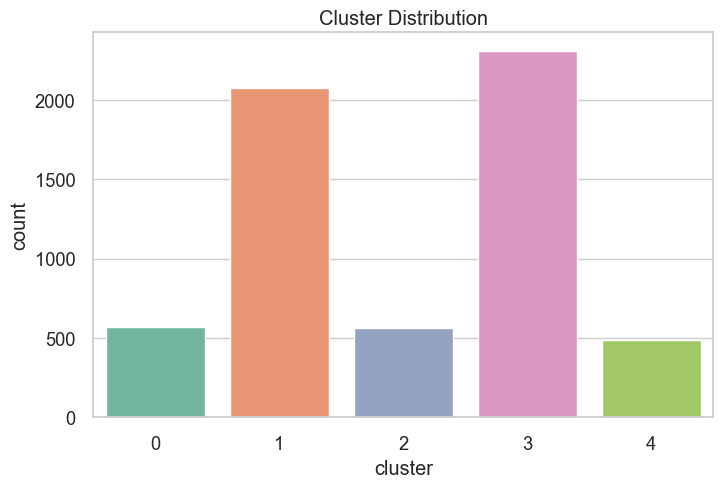

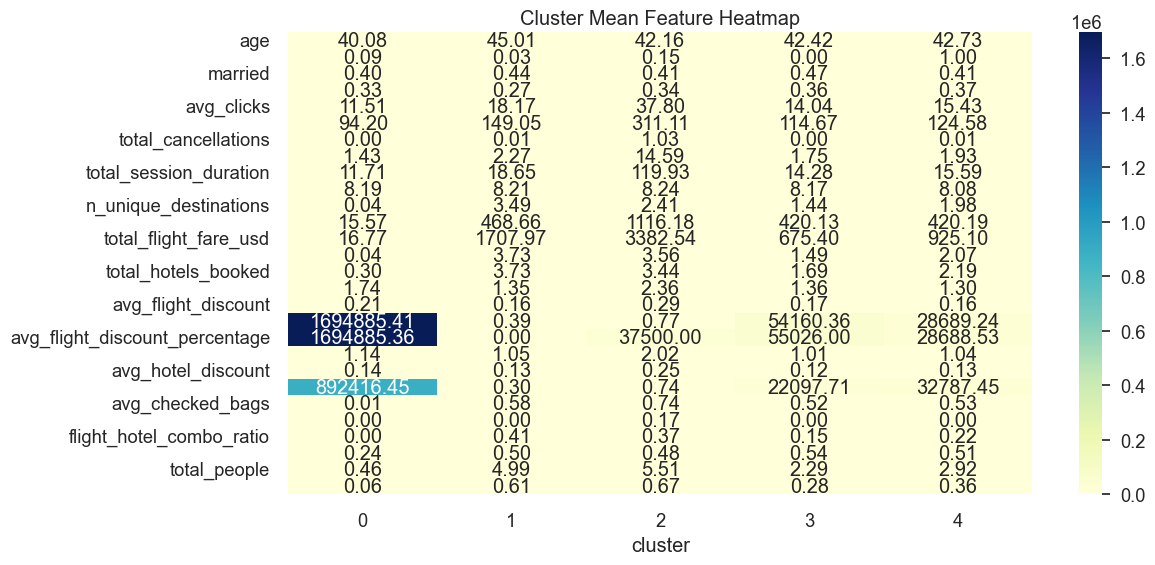

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


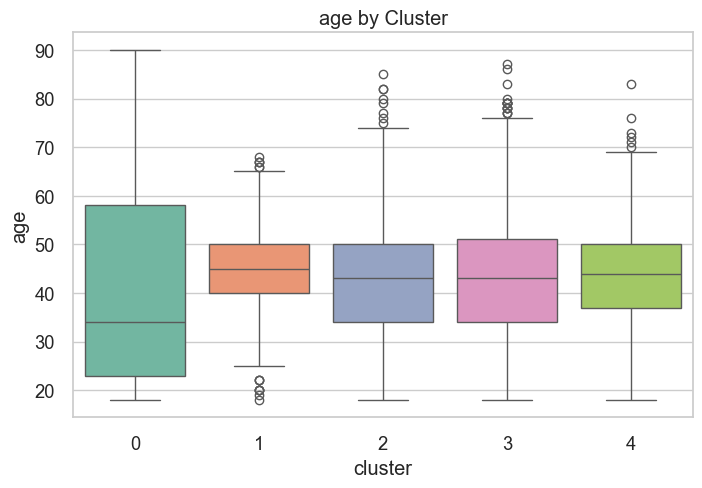

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


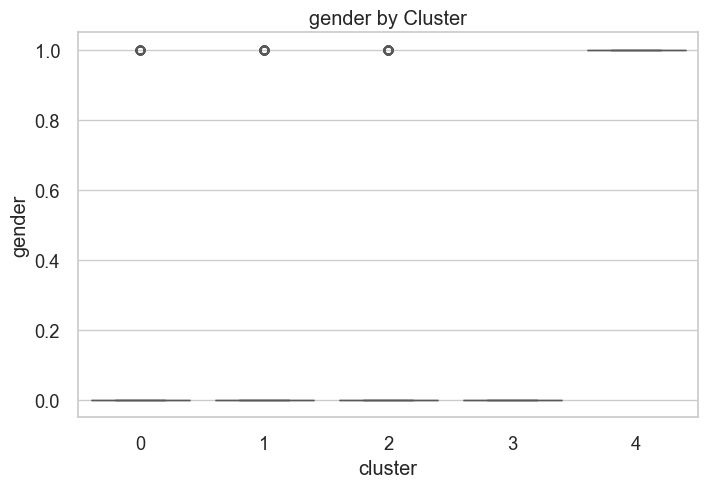

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


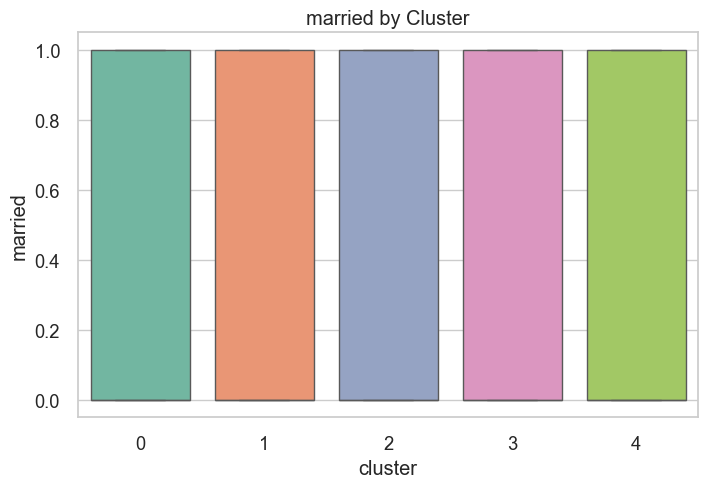

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


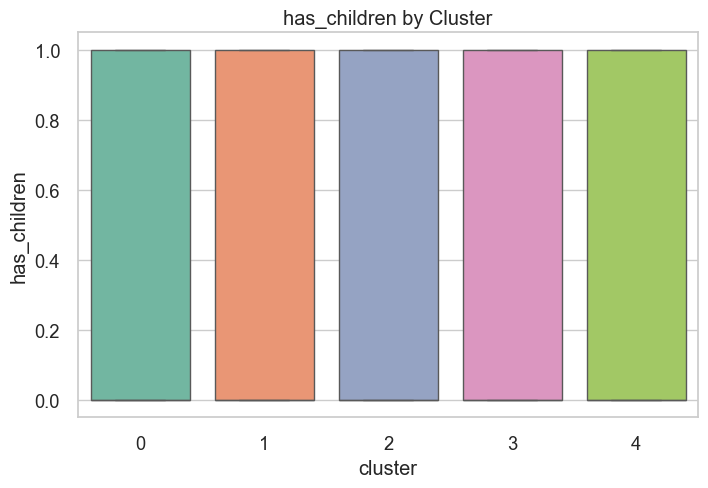

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


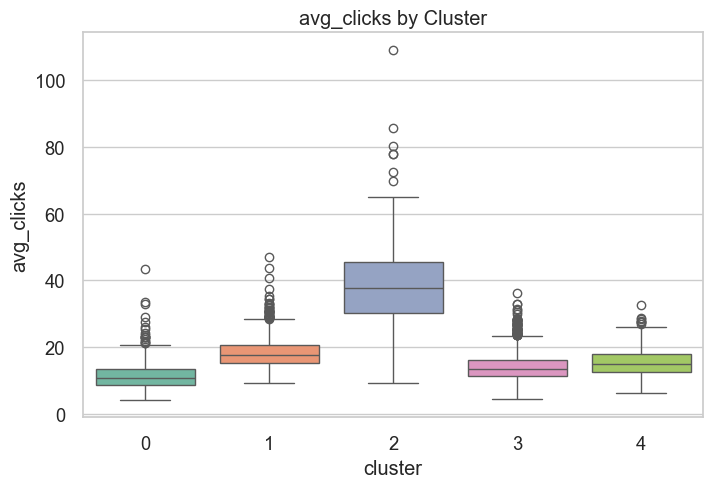

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


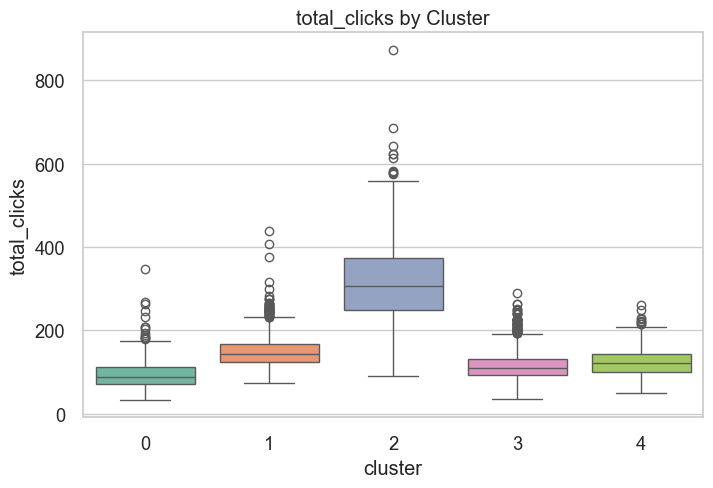

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


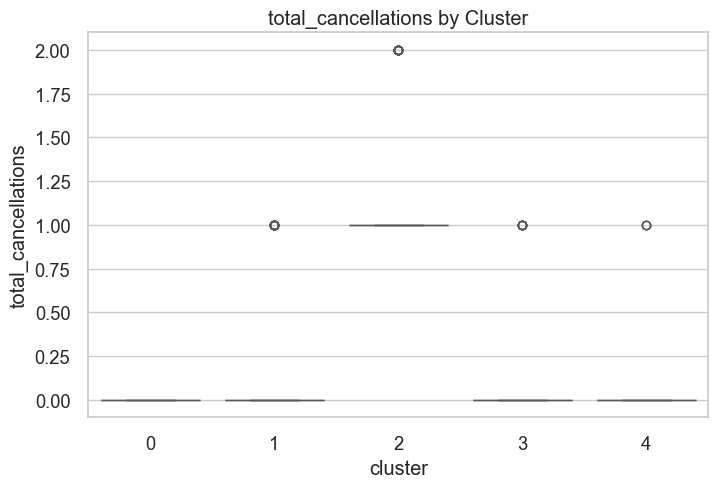

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


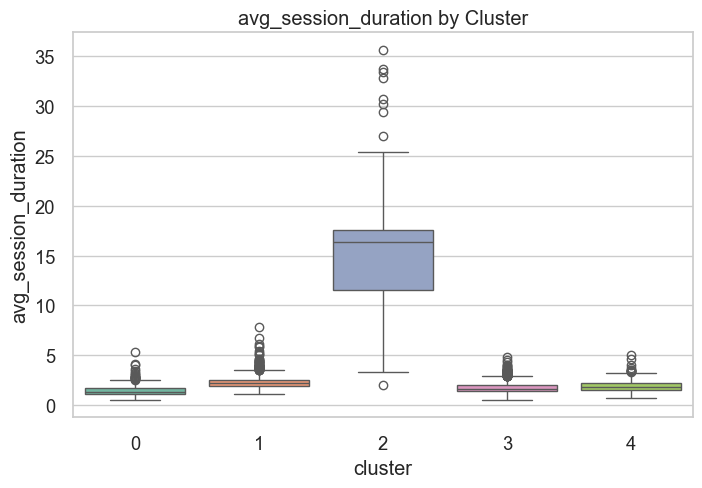

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


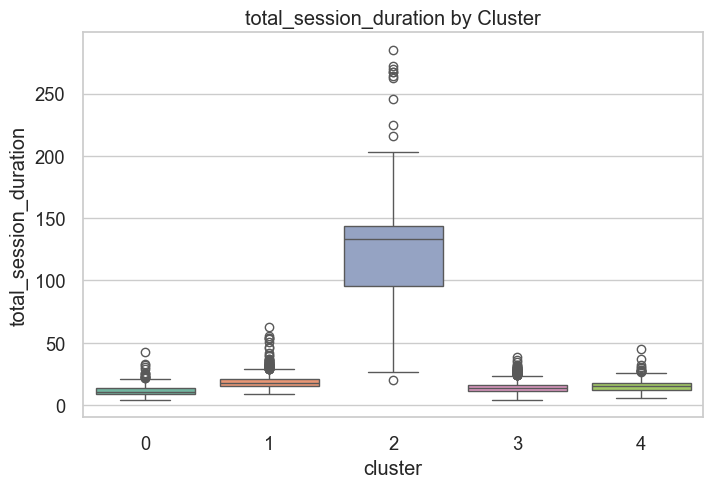

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


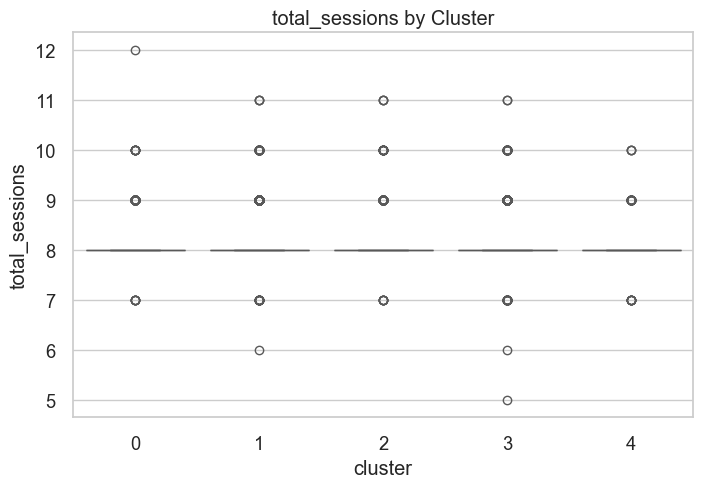

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


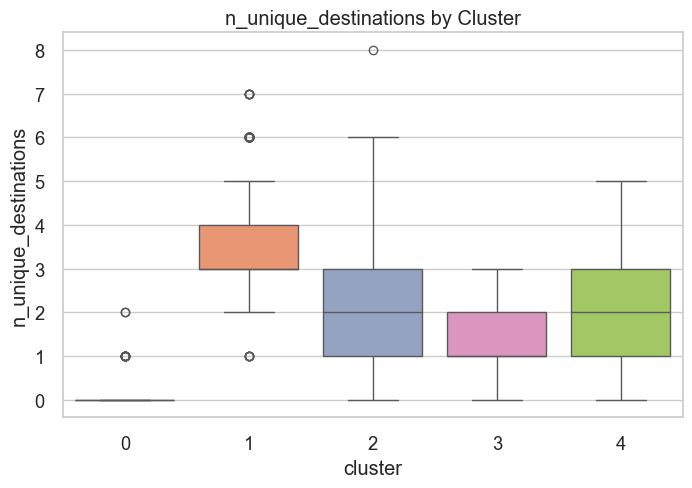

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


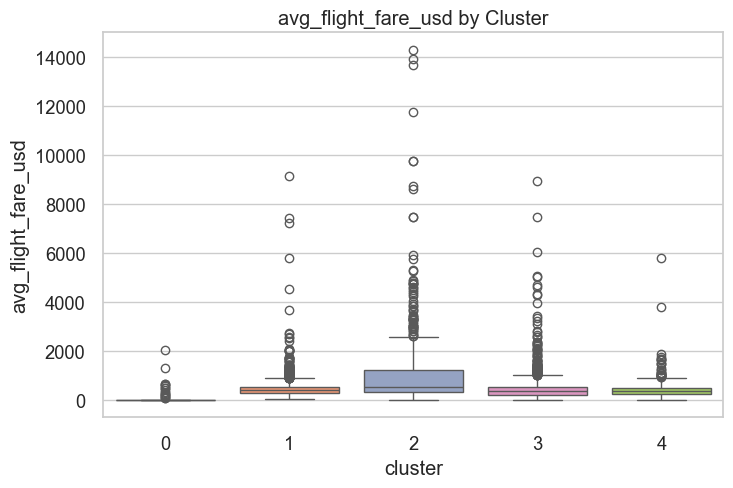

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


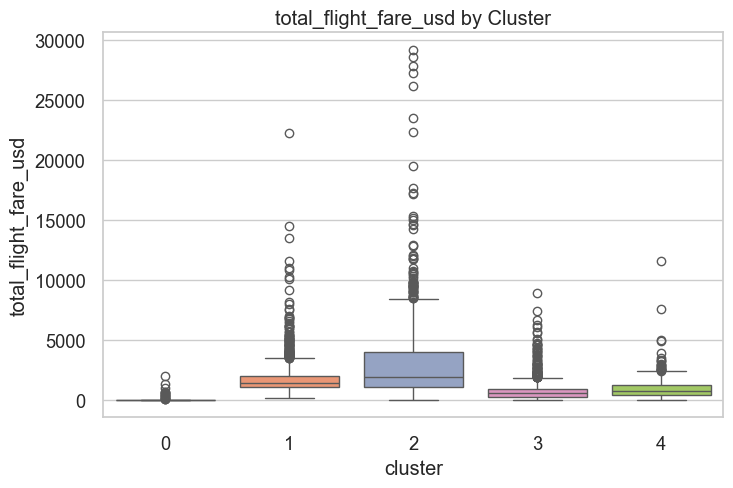

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


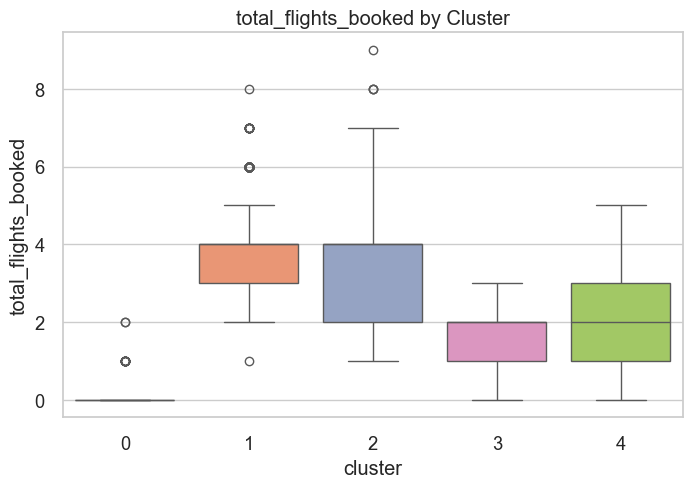

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


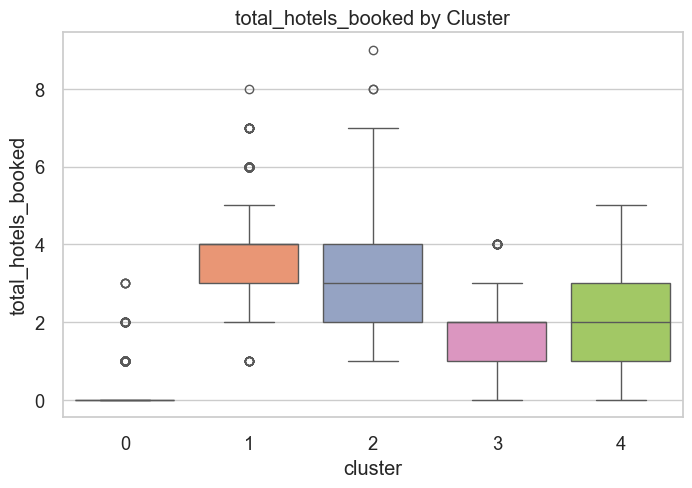

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


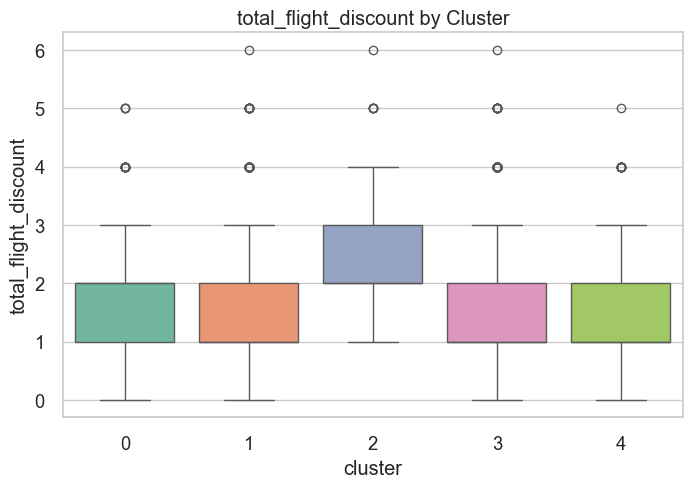

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


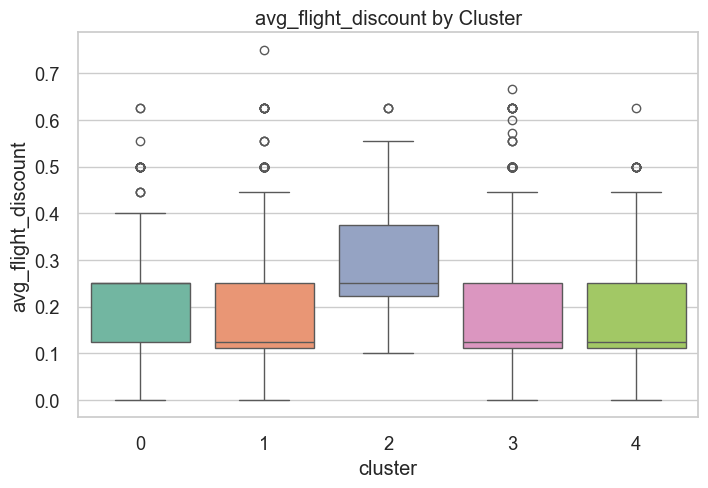

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


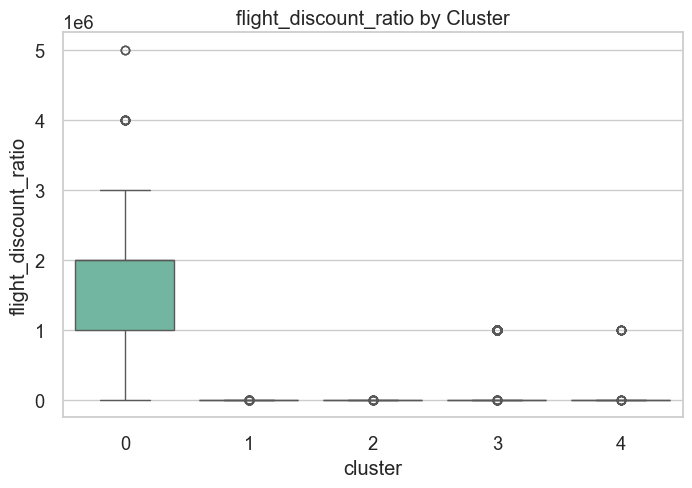

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


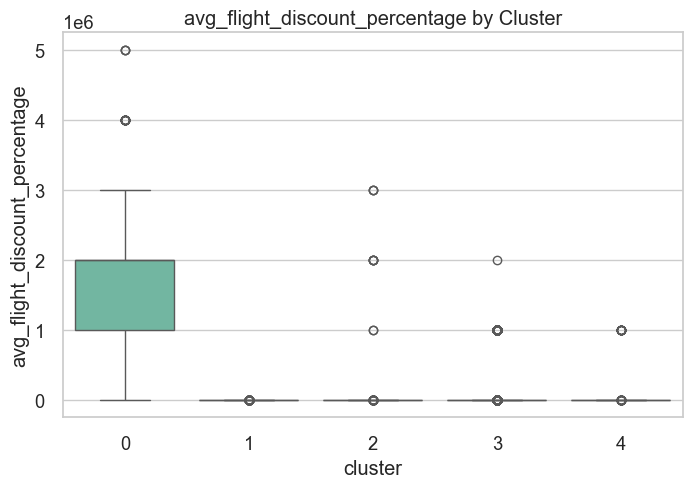

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


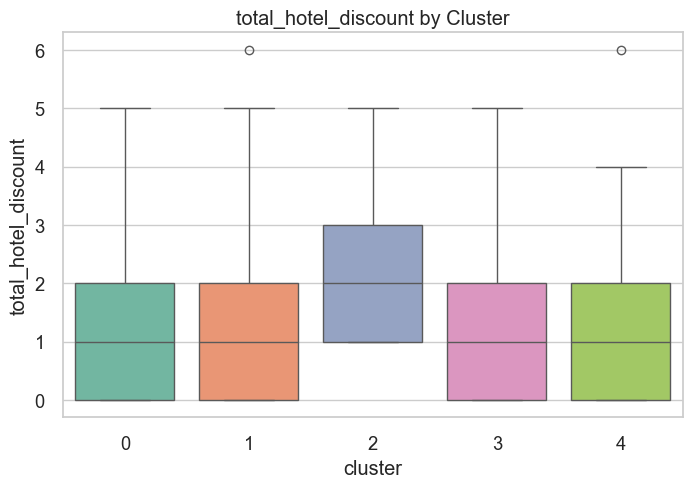

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


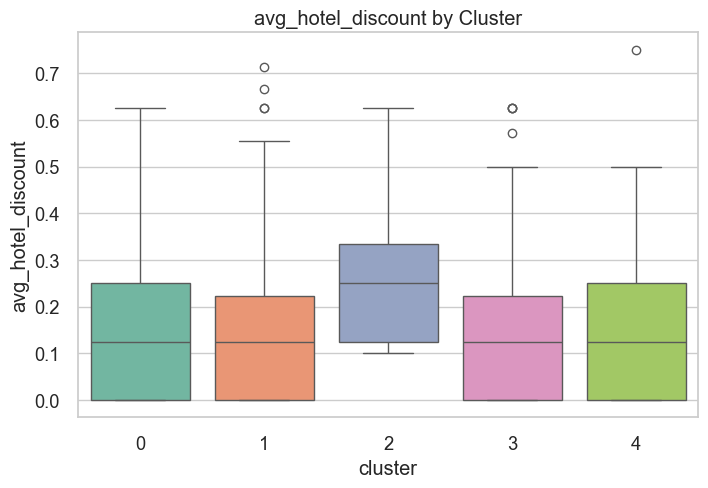

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


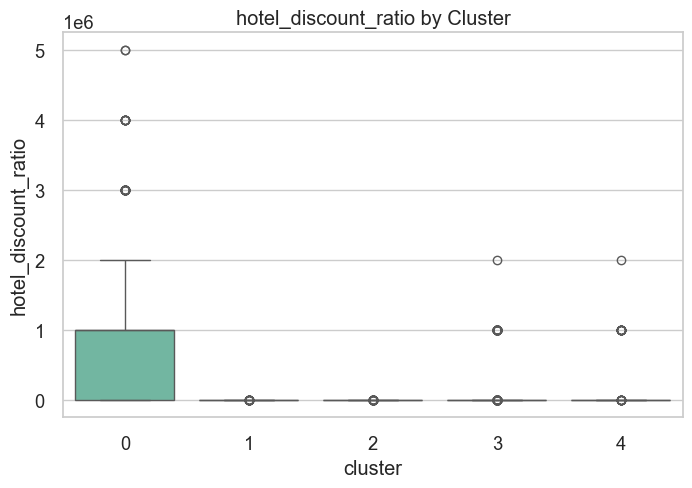

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


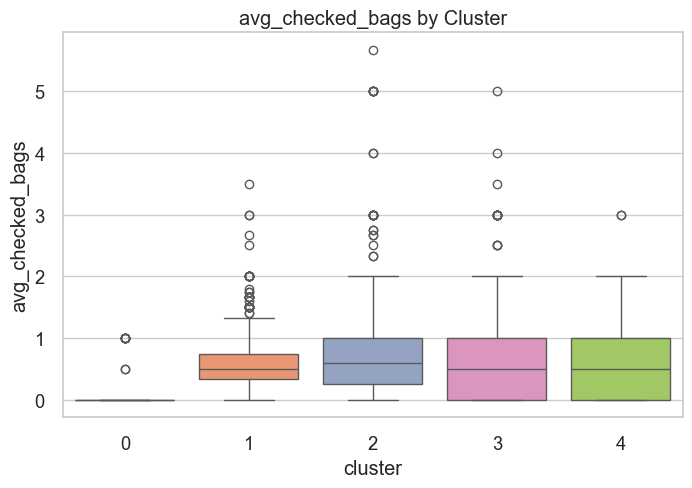

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


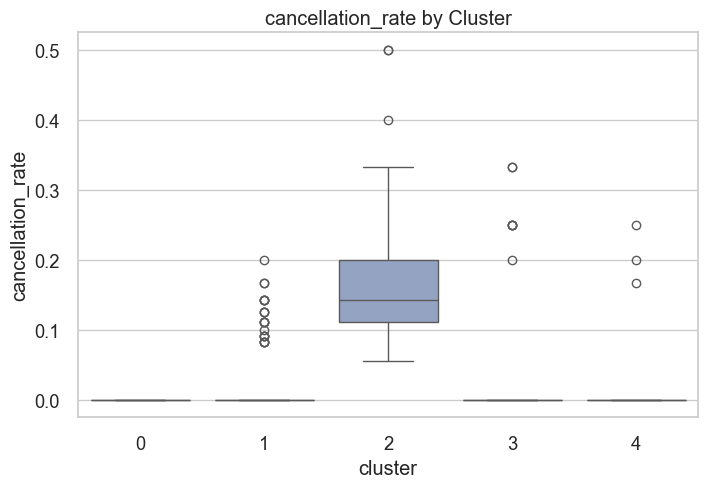

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


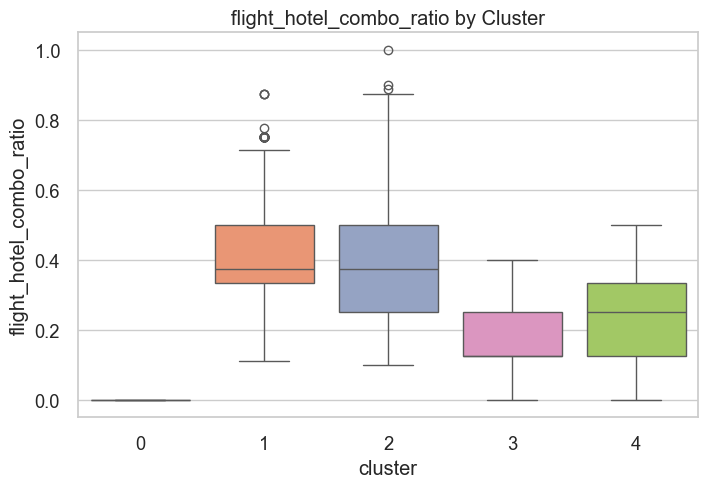

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


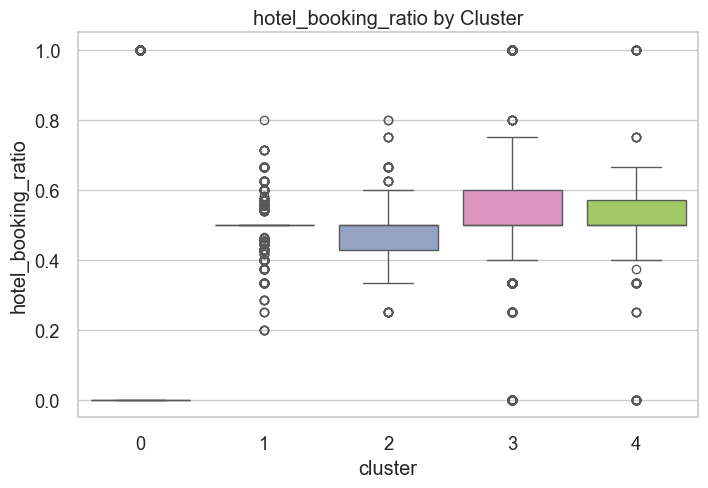

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


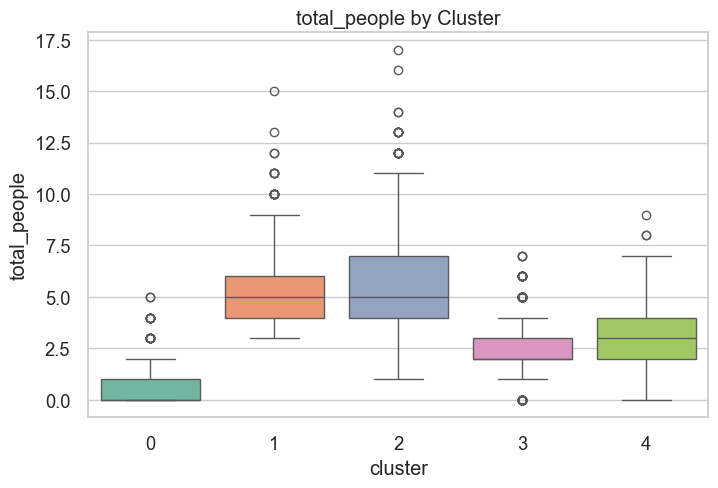

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")


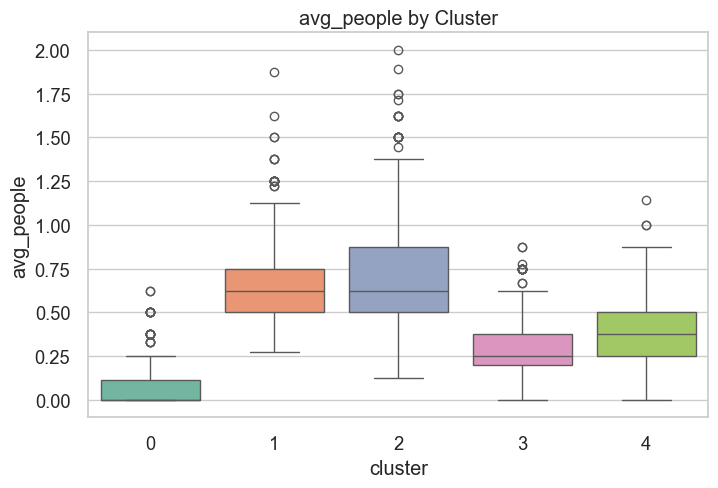

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


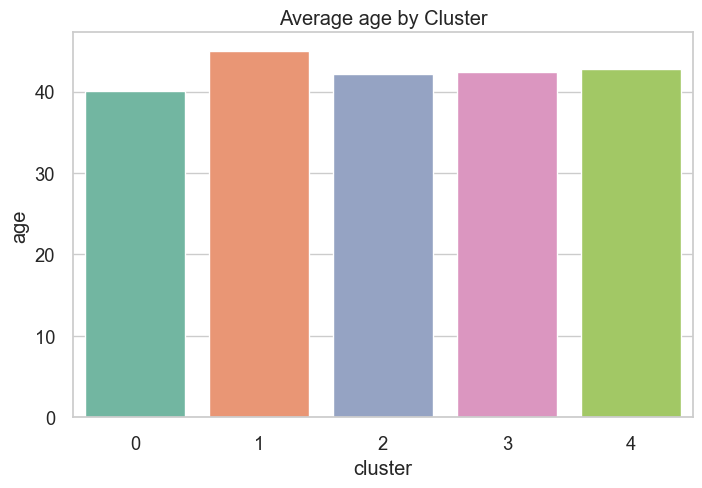

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


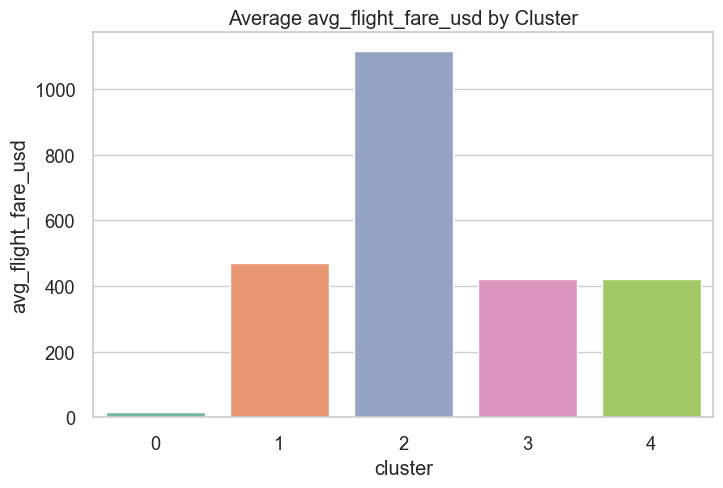

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


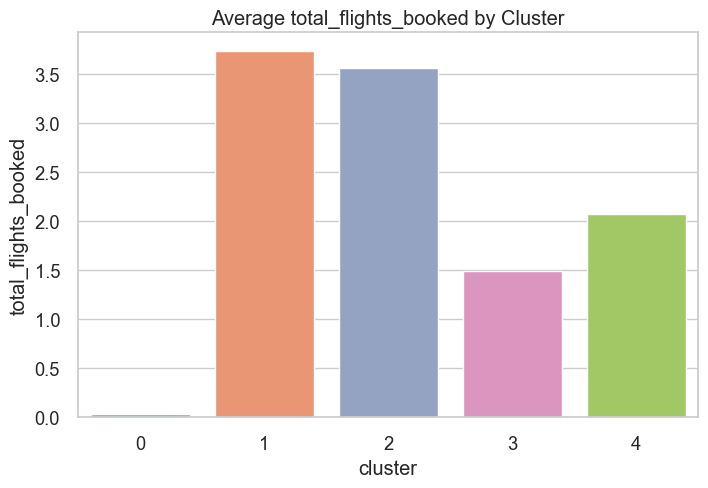

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


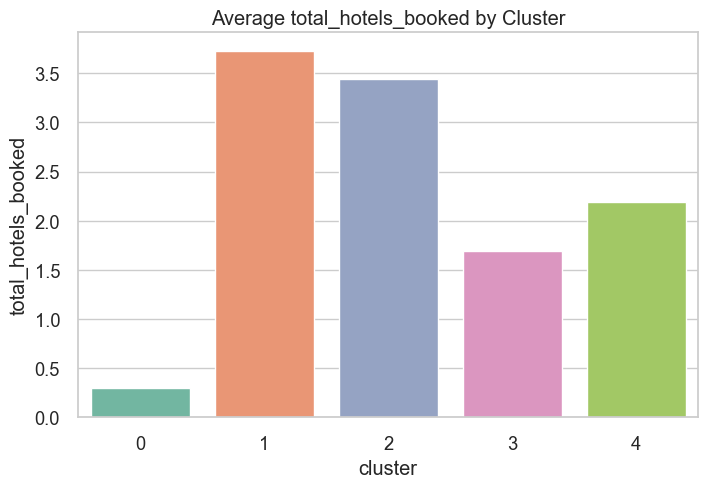

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


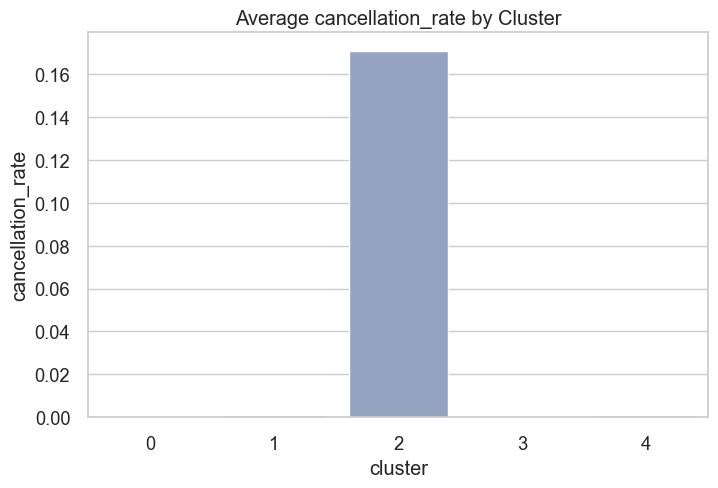

/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_23283/4208408492.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)


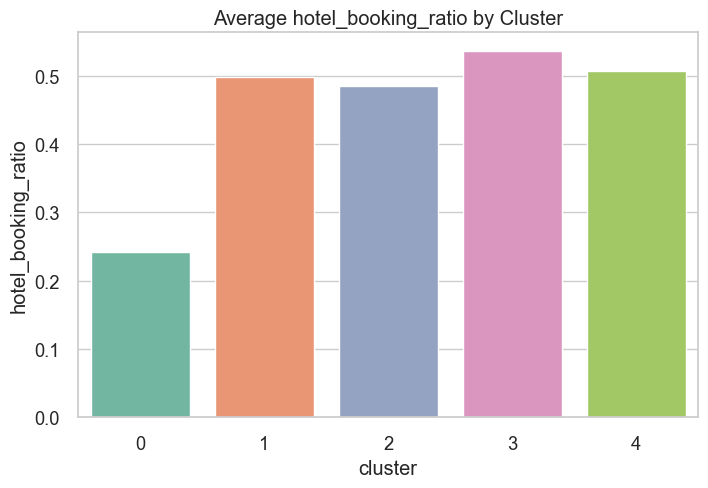

,age,gender,married,has_children,avg_clicks,total_clicks,total_cancellations,avg_session_duration,total_session_duration,total_sessions,...,avg_hotel_discount,hotel_discount_ratio,avg_checked_bags,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio,total_people,avg_people,n_users,perk
cluster,,,,,,,,,,,,,,,,,,,,,
0,40.08,0.09,0.40,0.33,11.51,94.20,0.00,1.43,11.71,8.19,...,0.14,892416.45,0.01,0.00,0.00,0.24,0.46,0.06,567,No Cancellation Fees
1,45.01,0.03,0.44,0.27,18.17,149.05,0.01,2.27,18.65,8.21,...,0.13,0.30,0.58,0.00,0.41,0.50,4.99,0.61,2075,Exclusive Discounts
2,42.16,0.15,0.41,0.34,37.80,311.11,1.03,14.59,119.93,8.24,...,0.25,0.74,0.74,0.17,0.37,0.48,5.51,0.67,560,Free Checked Bag
3,42.42,0.00,0.47,0.36,14.04,114.67,0.00,1.75,14.28,8.17,...,0.12,22097.71,0.52,0.00,0.15,0.54,2.29,0.28,2308,1 Night Free Hotel with flight
4,42.73,1.00,0.41,0.37,15.43,124.58,0.01,1.93,15.59,8.08,...,0.13,32787.45,0.53,0.00,0.22,0.51,2.92,0.36,488,Free Hotel Meal


In [ ]:
# --- Notebook: Cluster Insights & Perks ---

# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid", palette="Set2", font_scale=1.2)

# Load Data (falls nicht schon geladen)
# df_clusters = pd.read_csv("summary_clusters.csv")

# Define perks
perks = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel with flight",
    4: "Free Hotel Meal"
}

# Quick check
display(df_clusters.head())
print(df_clusters["cluster"].value_counts())

# --- Cluster Distribution ---
plt.figure(figsize=(8,5))
sns.countplot(data=df_clusters, x="cluster", palette="Set2")
plt.title("Cluster Distribution")
plt.show()

# --- Numeric Feature Overview ---
numeric_cols = df_clusters.select_dtypes(include=["int64","float64"]).columns

# Heatmap of mean values
cluster_means = df_clusters.groupby("cluster")[numeric_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means.T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cluster Mean Feature Heatmap")
plt.show()

# Boxplots for each feature
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set2")
    plt.title(f"{col} by Cluster")
    plt.show()

# --- Key Features (Barplots) ---
key_features = [
    "age", "avg_flight_fare_usd", "avg_hotel_spend_usd",
    "total_flights_booked", "total_hotels_booked",
    "cancellation_rate", "hotel_booking_ratio"
]

for col in key_features:
    if col in df_clusters.columns:
        plt.figure(figsize=(8,5))
        sns.barplot(data=df_clusters, x="cluster", y=col, palette="Set2", ci=None)
        plt.title(f"Average {col} by Cluster")
        plt.show()

# --- Final Profiles ---
cluster_profiles = df_clusters.groupby("cluster")[numeric_cols].mean().round(2)
cluster_profiles["n_users"] = df_clusters["cluster"].value_counts().sort_index()
cluster_profiles["perk"] = cluster_profiles.index.map(perks)

display(cluster_profiles)

In [ ]:
jj